**Environment check** — default Kaggle boilerplate that lists the files available under `/kaggle/input`.

In [148]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/train-images-idx3-ubyte


### Environment Setup
Import the libraries needed for this notebook and list the dataset files so we know the exact file paths to load.

In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/train-images-idx3-ubyte


Load the training and test CSV files and preview the first few rows of the training data.

In [150]:
df_train = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv')
df_test = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv')

print(df_train.shape)
print(df_test.shape)
df_train.head()

(60000, 785)
(10000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Check the training and test data for missing values and duplicate rows.

In [151]:
# Missing values check
print("Missing values in train:\n", df_train.isnull().sum().sum())
print("Missing values in test:\n", df_test.isnull().sum().sum())

# Duplicate rows check
print("\nDuplicate rows in train:", df_train.duplicated().sum())
print("Duplicate rows in test:", df_test.duplicated().sum())




Missing values in train:
 0
Missing values in test:
 0

Duplicate rows in train: 43
Duplicate rows in test: 1


Remove the duplicate rows found in the previous step (43 from train, 1 from test).

In [152]:
df_train = df_train.drop_duplicates().reset_index(drop=True)
df_test = df_test.drop_duplicates().reset_index(drop=True)

print("\nAfter removing duplicates:")
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)


After removing duplicates:
Train shape: (59957, 785)
Test shape: (9999, 785)


Check the class distribution (counts and percentages) for the train and test sets, with bar plots.

Train class distribution:
 label
5    6000
8    6000
0    5998
9    5998
3    5997
7    5996
1    5996
4    5995
6    5989
2    5988
Name: count, dtype: int64

Train class distribution (%):
 label
5    10.007172
8    10.007172
0    10.003836
9    10.003836
3    10.002168
7    10.000500
1    10.000500
4     9.998832
6     9.988825
2     9.987157
Name: proportion, dtype: float64

Test class distribution:
 label
1    1000
2    1000
5    1000
3    1000
8    1000
6    1000
7    1000
4    1000
9    1000
0     999
Name: count, dtype: int64

Test class distribution (%):
 label
1    10.001000
2    10.001000
5    10.001000
3    10.001000
8    10.001000
6    10.001000
7    10.001000
4    10.001000
9    10.001000
0     9.990999
Name: proportion, dtype: float64


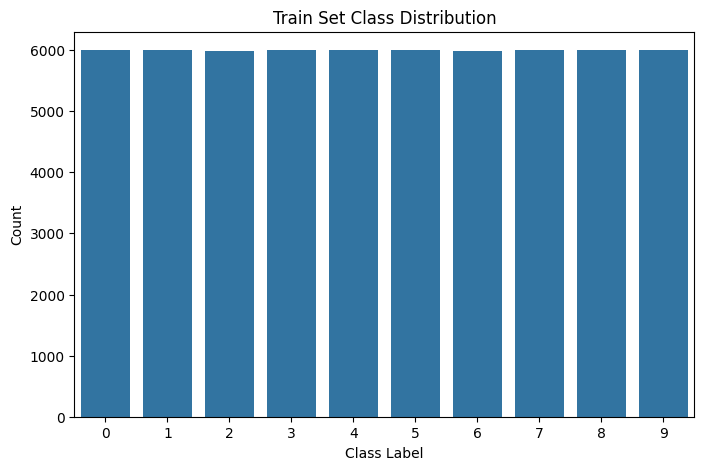

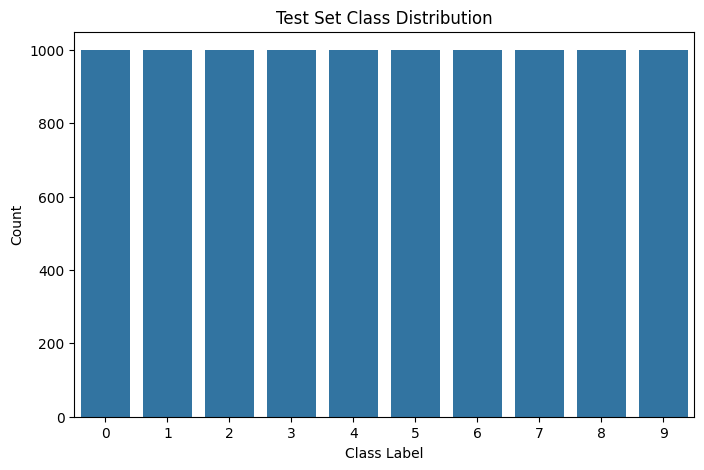

In [153]:
import seaborn as sns

# Class counts and percentages (train)
print("Train class distribution:\n", df_train['label'].value_counts())
print("\nTrain class distribution (%):\n", df_train['label'].value_counts(normalize=True) * 100)

# Class counts and percentages (test)
print("\nTest class distribution:\n", df_test['label'].value_counts())
print("\nTest class distribution (%):\n", df_test['label'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8,5))
sns.countplot(x='label', data=df_train)
plt.title("Train Set Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='label', data=df_test)
plt.title("Test Set Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.show()

Display one sample image from each of the 10 clothing classes, just to see what the data looks like.

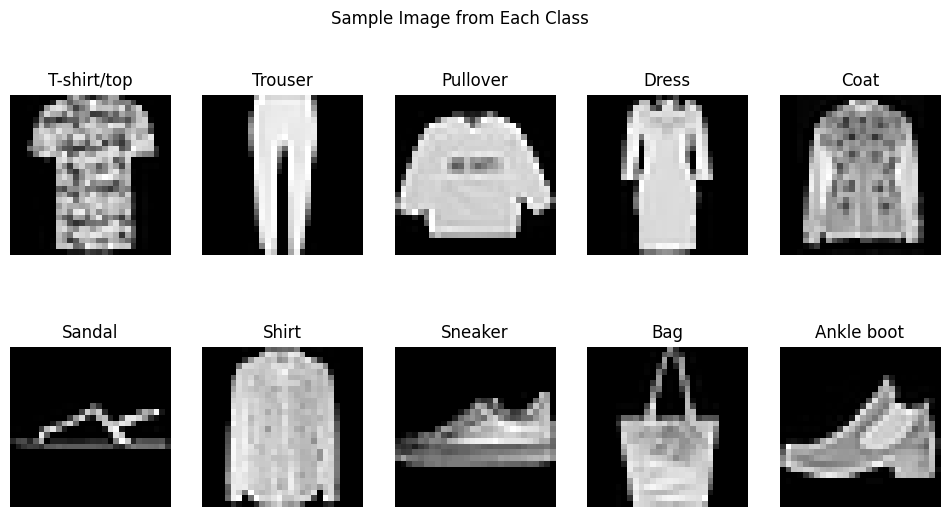

In [154]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(12,6))
for i in range(10):
    img = df_train[df_train['label'] == i].iloc[0, 1:].values.reshape(28,28)
    plt.subplot(2,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(class_names[i])
    plt.axis('off')
plt.suptitle("Sample Image from Each Class")
plt.show()

Separate features and labels, normalize pixel values to the 0–1 range, and split the training data 80/20 into a training set and a validation set (stratified so class balance is preserved).

In [155]:
# Separate features and labels
X = df_train.drop('label', axis=1).values
y = df_train['label'].values

X_test = df_test.drop('label', axis=1).values
y_test = df_test['label'].values

# Normalize pixel values to 0-1
X = X / 255.0
X_test = X_test / 255.0

print("X shape (flattened, normalized):", X.shape)
print("X_test shape (flattened, normalized):", X_test.shape)

# 80/20 stratified split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

X shape (flattened, normalized): (59957, 784)
X_test shape (flattened, normalized): (9999, 784)

Train shape: (47965, 784)
Validation shape: (11992, 784)
Test shape: (9999, 784)


Confirm that the class distribution is balanced across the train, validation, and test splits after the split.

In [156]:
print("Train class distribution (%):\n", pd.Series(y_train).value_counts(normalize=True).sort_index() * 100)
print("\nValidation class distribution (%):\n", pd.Series(y_val).value_counts(normalize=True).sort_index() * 100)
print("\nTest class distribution (%):\n", pd.Series(y_test).value_counts(normalize=True).sort_index() * 100)

Train class distribution (%):
 0    10.003127
1    10.001042
2     9.986448
3    10.003127
4     9.998958
5    10.007297
6     9.988533
7    10.001042
8    10.007297
9    10.003127
Name: proportion, dtype: float64

Validation class distribution (%):
 0    10.006671
1     9.998332
2     9.989993
3     9.998332
4     9.998332
5    10.006671
6     9.989993
7     9.998332
8    10.006671
9    10.006671
Name: proportion, dtype: float64

Test class distribution (%):
 0     9.990999
1    10.001000
2    10.001000
3    10.001000
4    10.001000
5    10.001000
6    10.001000
7    10.001000
8    10.001000
9    10.001000
Name: proportion, dtype: float64


One-hot encode the labels. This isn't needed for Part 1's cross-entropy loss, but it will be used later for the MSE loss comparison in Part 3.

In [157]:
from tensorflow.keras.utils import to_categorical

# One-hot encode labels (will be needed later for MSE loss in Part 3)
y_train_onehot = to_categorical(y_train, num_classes=10)
y_val_onehot = to_categorical(y_val, num_classes=10)
y_test_onehot = to_categorical(y_test, num_classes=10)

print("y_train_onehot shape:", y_train_onehot.shape)
print("Example label:", y_train[0], "-> one-hot:", y_train_onehot[0])

y_train_onehot shape: (47965, 10)
Example label: 7 -> one-hot: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


### Part 1: Backpropagation From Scratch (NumPy only)
Randomly initialize the weights and biases of a 2-layer network (784 → 64 → 10).

In [158]:
np.random.seed(42)

# Network architecture: 784 -> 64 -> 10
input_size = 784
hidden_size = 64
output_size = 10

# Random initialization (small scale)
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (784, 64)
b1 shape: (1, 64)
W2 shape: (64, 10)
b2 shape: (1, 10)


Define the ReLU activation, a numerically stable softmax, and the forward pass function.

In [159]:
def relu(Z):
    return np.maximum(0, Z)

def softmax(Z):
    # Numerically stable softmax (subtract max value per row)
    Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(Z_shifted)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

def forward_pass(X, W1, b1, W2, b2):
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)
    
    cache = (Z1, A1, Z2, A2)
    return A2, cache

Define the categorical cross-entropy loss function (using one-hot targets).

In [160]:
def compute_loss(y_true_onehot, y_pred):
    m = y_true_onehot.shape[0]
    # Categorical cross-entropy with one-hot targets
    log_probs = -np.sum(y_true_onehot * np.log(y_pred + 1e-8), axis=1)
    loss = np.sum(log_probs) / m
    return loss

Define the backward pass — the manual gradient computation via backpropagation.

In [161]:
def backward_pass(X, y_true_onehot, cache, W1, W2):
    m = X.shape[0]
    Z1, A1, Z2, A2 = cache
    
    # Output layer gradient (softmax + cross-entropy combined derivative)
    dZ2 = (A2 - y_true_onehot) / m
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    
    # Hidden layer gradient
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * (Z1 > 0)  # ReLU derivative
    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    
    grads = (dW1, db1, dW2, db2)
    return grads

Take a random 5,000-sample subset of the training data, as required for Part 1.

In [162]:
np.random.seed(42)
subset_indices = np.random.choice(X_train.shape[0], 5000, replace=False)

X_subset = X_train[subset_indices]
y_subset = y_train[subset_indices]
y_subset_onehot = y_train_onehot[subset_indices]

print("X_subset shape:", X_subset.shape)
print("y_subset shape:", y_subset.shape)
print("y_subset_onehot shape:", y_subset_onehot.shape)

X_subset shape: (5000, 784)
y_subset shape: (5000,)
y_subset_onehot shape: (5000, 10)


Train the network for 20 epochs using manual gradient descent (learning rate = 0.5) and record the loss at each epoch.

In [163]:
learning_rate = 0.5
epochs = 20
loss_history = []

for epoch in range(epochs):
    # Forward pass
    A2, cache = forward_pass(X_subset, W1, b1, W2, b2)
    
    # Compute loss
    loss = compute_loss(y_subset_onehot, A2)
    loss_history.append(loss)
    
    # Backward pass
    dW1, db1, dW2, db2 = backward_pass(X_subset, y_subset_onehot, cache, W1, W2)
    
    # Manual gradient descent update
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    
    print(f"Epoch {epoch+1}/{epochs} - Loss: {loss:.4f}")

Epoch 1/20 - Loss: 2.3046
Epoch 2/20 - Loss: 2.2975
Epoch 3/20 - Loss: 2.2883
Epoch 4/20 - Loss: 2.2704
Epoch 5/20 - Loss: 2.2366
Epoch 6/20 - Loss: 2.1800
Epoch 7/20 - Loss: 2.0987
Epoch 8/20 - Loss: 1.9902
Epoch 9/20 - Loss: 1.8521
Epoch 10/20 - Loss: 1.7033
Epoch 11/20 - Loss: 1.5726
Epoch 12/20 - Loss: 1.4668
Epoch 13/20 - Loss: 1.3831
Epoch 14/20 - Loss: 1.3402
Epoch 15/20 - Loss: 1.6824
Epoch 16/20 - Loss: 3.1687
Epoch 17/20 - Loss: 2.1061
Epoch 18/20 - Loss: 2.0106
Epoch 19/20 - Loss: 1.9518
Epoch 20/20 - Loss: 1.7321


Plot the training loss curve for the first run (learning rate = 0.5).

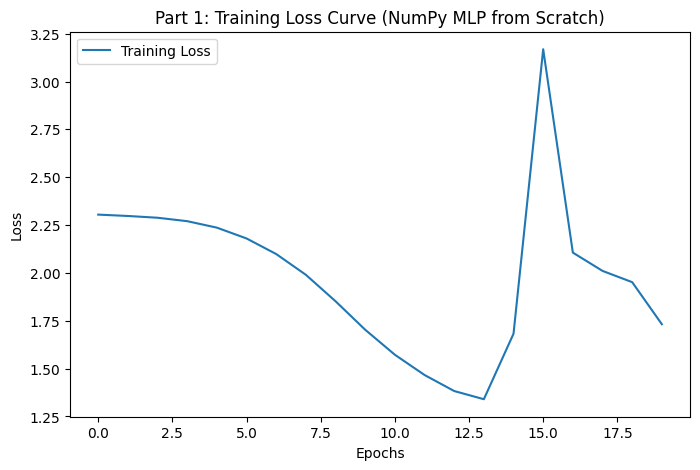

In [164]:
plt.figure(figsize=(8,5))
plt.plot(loss_history, label='Training Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Part 1: Training Loss Curve (NumPy MLP from Scratch)")
plt.legend()
plt.show()

The previous run showed an unstable spike in the loss, so retrain from scratch with a lower learning rate (0.1) for a smoother curve.

In [165]:
learning_rate = 0.1
epochs = 20
loss_history = []

for epoch in range(epochs):
    A2, cache = forward_pass(X_subset, W1, b1, W2, b2)
    loss = compute_loss(y_subset_onehot, A2)
    loss_history.append(loss)
    
    dW1, db1, dW2, db2 = backward_pass(X_subset, y_subset_onehot, cache, W1, W2)
    
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    
    print(f"Epoch {epoch+1}/{epochs} - Loss: {loss:.4f}")

Epoch 1/20 - Loss: 1.6253
Epoch 2/20 - Loss: 1.5970
Epoch 3/20 - Loss: 1.5766
Epoch 4/20 - Loss: 1.5590
Epoch 5/20 - Loss: 1.5423
Epoch 6/20 - Loss: 1.5259
Epoch 7/20 - Loss: 1.5098
Epoch 8/20 - Loss: 1.4935
Epoch 9/20 - Loss: 1.4771
Epoch 10/20 - Loss: 1.4601
Epoch 11/20 - Loss: 1.4427
Epoch 12/20 - Loss: 1.4248
Epoch 13/20 - Loss: 1.4062
Epoch 14/20 - Loss: 1.3872
Epoch 15/20 - Loss: 1.3679
Epoch 16/20 - Loss: 1.3482
Epoch 17/20 - Loss: 1.3284
Epoch 18/20 - Loss: 1.3088
Epoch 19/20 - Loss: 1.2894
Epoch 20/20 - Loss: 1.2704


Plot the training loss curve for the corrected run (learning rate = 0.1).

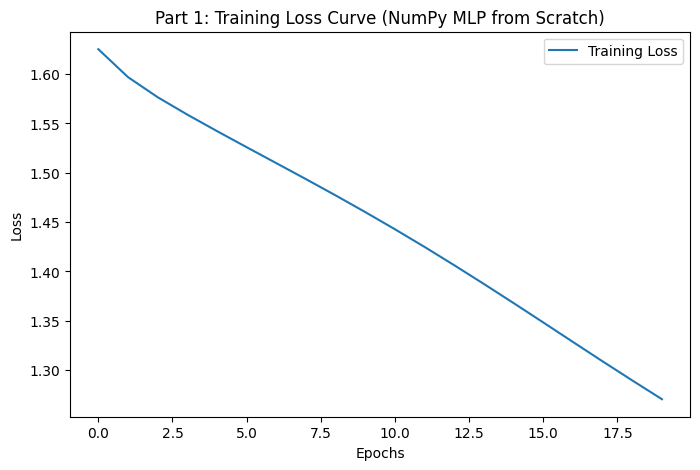

In [166]:
plt.figure(figsize=(8,5))
plt.plot(loss_history, label='Training Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Part 1: Training Loss Curve (NumPy MLP from Scratch)")
plt.legend()
plt.show()

Re-initialize a fresh set of weights (kept separate from the already-trained ones) to use for gradient verification.

In [167]:
np.random.seed(42)

W1_check = np.random.randn(input_size, hidden_size) * 0.01
b1_check = np.zeros((1, hidden_size))

W2_check = np.random.randn(hidden_size, output_size) * 0.01
b2_check = np.zeros((1, output_size))

print("Fresh weights re-initialized for gradient checking")

Fresh weights re-initialized for gradient checking


Run one forward pass and one backward pass in NumPy on a small batch, using the fresh weights.

In [168]:
# Use a small batch for gradient checking
X_batch = X_subset[:32]
y_batch_onehot = y_subset_onehot[:32]

# Forward pass
A2_check, cache_check = forward_pass(X_batch, W1_check, b1_check, W2_check, b2_check)

# Backward pass
dW1_numpy, db1_numpy, dW2_numpy, db2_numpy = backward_pass(X_batch, y_batch_onehot, cache_check, W1_check, W2_check)

print("NumPy dW1 shape:", dW1_numpy.shape)
print("NumPy dW2 shape:", dW2_numpy.shape)

NumPy dW1 shape: (784, 64)
NumPy dW2 shape: (64, 10)


Rebuild the same network in PyTorch with the exact same initial weights, and run the same forward and backward pass using autograd.

In [169]:
import torch
import torch.nn as nn

# Copy exact same weights from NumPy into PyTorch tensors
W1_torch = torch.tensor(W1_check, dtype=torch.float64, requires_grad=True)
b1_torch = torch.tensor(b1_check, dtype=torch.float64, requires_grad=True)
W2_torch = torch.tensor(W2_check, dtype=torch.float64, requires_grad=True)
b2_torch = torch.tensor(b2_check, dtype=torch.float64, requires_grad=True)

X_batch_torch = torch.tensor(X_batch, dtype=torch.float64)
y_batch_torch = torch.tensor(y_batch_onehot, dtype=torch.float64)

# Forward pass (same architecture)
Z1_torch = X_batch_torch @ W1_torch + b1_torch
A1_torch = torch.relu(Z1_torch)
Z2_torch = A1_torch @ W2_torch + b2_torch
A2_torch = torch.softmax(Z2_torch, dim=1)

# Loss (categorical cross-entropy with one-hot targets)
loss_torch = -torch.sum(y_batch_torch * torch.log(A2_torch + 1e-8)) / X_batch_torch.shape[0]

# Backward pass (autograd)
loss_torch.backward()

print("PyTorch loss:", loss_torch.item())

PyTorch loss: 2.3041665711131087


Compare the NumPy gradients to PyTorch's autograd gradients and print the maximum absolute difference for each weight matrix.

In [170]:
diff_W1 = np.max(np.abs(dW1_numpy - W1_torch.grad.numpy()))
diff_b1 = np.max(np.abs(db1_numpy - b1_torch.grad.numpy()))
diff_W2 = np.max(np.abs(dW2_numpy - W2_torch.grad.numpy()))
diff_b2 = np.max(np.abs(db2_numpy - b2_torch.grad.numpy()))

print("Max absolute difference in dW1:", diff_W1)
print("Max absolute difference in db1:", diff_b1)
print("Max absolute difference in dW2:", diff_W2)
print("Max absolute difference in db2:", diff_b2)

Max absolute difference in dW1: 3.763812941870448e-10
Max absolute difference in db1: 3.110941322256866e-10
Max absolute difference in dW2: 4.185286776869912e-09
Max absolute difference in db2: 6.889588580194506e-09


## Part 1 Conclusion: Gradient Verification

The maximum absolute differences between the NumPy-computed gradients and PyTorch's 
autograd-computed gradients were:

- dW1: 3.76 × 10⁻¹⁰
- db1: 3.11 × 10⁻¹⁰
- dW2: 4.19 × 10⁻⁹
- db2: 6.89 × 10⁻⁹

All differences are on the order of 1e-9 to 1e-10, which is within normal floating-point 
precision error and not indicative of any implementation bug. This confirms that the 
manually implemented forward pass, backward pass, and gradient computations in NumPy 
are mathematically correct and match the automatic differentiation results from PyTorch.


### Part 2: Baseline Model and Activation Study
Import the Keras layers and modules needed for the activation function comparison.

In [171]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

Define a helper function that computes the mean absolute gradient of a model's first hidden layer, using `tf.GradientTape`.

In [172]:
def get_first_layer_grad(model, X_batch, y_batch_onehot):
    X_tensor = tf.convert_to_tensor(X_batch, dtype=tf.float32)
    y_tensor = tf.convert_to_tensor(y_batch_onehot, dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        predictions = model(X_tensor, training=True)
        loss = tf.keras.losses.categorical_crossentropy(y_tensor, predictions)
        loss = tf.reduce_mean(loss)
    
    gradients = tape.gradient(loss, model.trainable_variables)
    mean_abs_grad = tf.reduce_mean(tf.abs(gradients[0])).numpy()
    return mean_abs_grad

Build the sigmoid-activation model (2 hidden layers of 128 and 64 units).

In [173]:
model_sigmoid = Sequential()
model_sigmoid.add(Dense(128, input_dim=784, activation='sigmoid'))
model_sigmoid.add(Dense(64, activation='sigmoid'))
model_sigmoid.add(Dense(10, activation='softmax'))

model_sigmoid.compile(optimizer=Adam(learning_rate=0.001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

model_sigmoid.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_63"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_223 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_224 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_225 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Train the sigmoid model one epoch at a time, capturing the first hidden layer's gradient at epoch 1 and at the final epoch.

In [174]:
X_grad_batch = X_val[:128]
y_grad_batch = y_val_onehot[:128]

history_sigmoid = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

for epoch in range(20):
    h = model_sigmoid.fit(X_train, y_train_onehot,
                           validation_data=(X_val, y_val_onehot),
                           epochs=1,
                           batch_size=128,
                           verbose=1)
    
    history_sigmoid['loss'].append(h.history['loss'][0])
    history_sigmoid['val_loss'].append(h.history['val_loss'][0])
    history_sigmoid['accuracy'].append(h.history['accuracy'][0])
    history_sigmoid['val_accuracy'].append(h.history['val_accuracy'][0])
    
    if epoch == 0:
        grad_epoch1_sigmoid = get_first_layer_grad(model_sigmoid, X_grad_batch, y_grad_batch)
    if epoch == 19:
        grad_final_sigmoid = get_first_layer_grad(model_sigmoid, X_grad_batch, y_grad_batch)

print("Sigmoid - Mean abs gradient at epoch 1:", grad_epoch1_sigmoid)
print("Sigmoid - Mean abs gradient at final epoch:", grad_final_sigmoid)

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7252 - loss: 0.9184 - val_accuracy: 0.8195 - val_loss: 0.5396
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8344 - loss: 0.4750 - val_accuracy: 0.8461 - val_loss: 0.4310
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8528 - loss: 0.4120 - val_accuracy: 0.8537 - val_loss: 0.4063
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8637 - loss: 0.3804 - val_accuracy: 0.8599 - val_loss: 0.3828
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8707 - loss: 0.3592 - val_accuracy: 0.8651 - val_loss: 0.3686
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8776 - loss: 0.3430 - val_accuracy: 0.8727 - val_loss: 0.3572
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8815 - loss: 0.3297 - val_accuracy: 0.8763 - val_loss: 0.3455
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8857 - loss: 0.3180 - val_accuracy: 0.8775 - val_loss: 0.3385
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8884 - lo

Evaluate the sigmoid model on the validation set.

In [175]:
loss_sigmoid, acc_sigmoid = model_sigmoid.evaluate(X_val, y_val_onehot, verbose=0)
print("Sigmoid Validation Loss:", loss_sigmoid)
print("Sigmoid Validation Accuracy:", acc_sigmoid)

Sigmoid Validation Loss: 0.304607629776001
Sigmoid Validation Accuracy: 0.8893429040908813


Plot the sigmoid model's training/validation loss and accuracy curves.

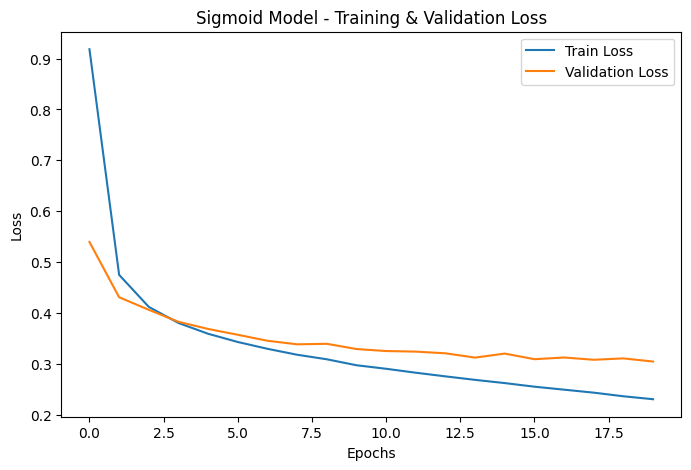

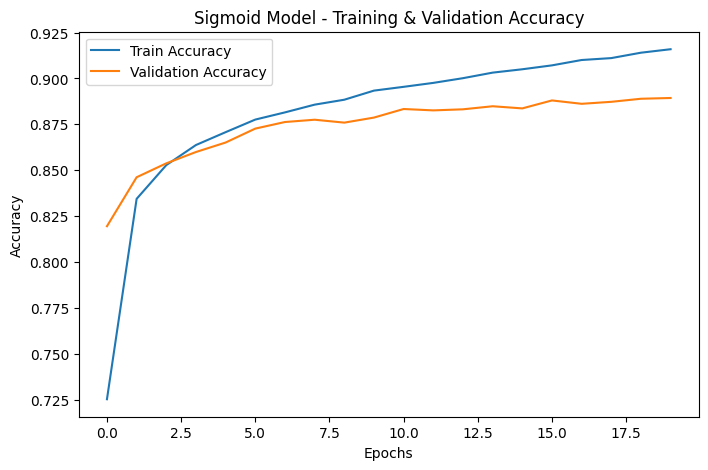

In [176]:
plt.figure(figsize=(8,5))
plt.plot(history_sigmoid['loss'], label='Train Loss')
plt.plot(history_sigmoid['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Sigmoid Model - Training & Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_sigmoid['accuracy'], label='Train Accuracy')
plt.plot(history_sigmoid['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Sigmoid Model - Training & Validation Accuracy")
plt.legend()
plt.show()

Build the tanh-activation model (same architecture as sigmoid).

In [177]:
model_tanh = Sequential()
model_tanh.add(Dense(128, input_dim=784, activation='tanh'))
model_tanh.add(Dense(64, activation='tanh'))
model_tanh.add(Dense(10, activation='softmax'))

model_tanh.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

model_tanh.summary()

Model: "sequential_64"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_226 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_227 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_228 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Train the tanh model for 20 epochs.

In [178]:
history_tanh = model_tanh.fit(X_train, y_train_onehot,
                               validation_data=(X_val, y_val_onehot),
                               epochs=20,
                               batch_size=128,
                               verbose=1)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8074 - loss: 0.5468 - val_accuracy: 0.8346 - val_loss: 0.4504
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8582 - loss: 0.3960 - val_accuracy: 0.8640 - val_loss: 0.3735
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8691 - loss: 0.3580 - val_accuracy: 0.8722 - val_loss: 0.3515
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8797 - loss: 0.3326 - val_accuracy: 0.8577 - val_loss: 0.3823
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8852 - loss: 0.3158 - val_accuracy: 0.8744 - val_loss: 0.3422
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8918 - loss: 0.2977 - val_accuracy: 0.8815 - val_loss: 0.3210
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8965 - loss: 0.2844 - val_accuracy: 0.8807 - val_loss: 0.3225
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8985 - loss: 0.2737 - val_accuracy: 0.

Evaluate the tanh model on the validation set.

In [179]:
loss_tanh, acc_tanh = model_tanh.evaluate(X_val, y_val_onehot, verbose=0)
print("Tanh Validation Loss:", loss_tanh)
print("Tanh Validation Accuracy:", acc_tanh)

Tanh Validation Loss: 0.3193739354610443
Tanh Validation Accuracy: 0.8885924220085144


Plot the tanh model's training/validation loss and accuracy curves.

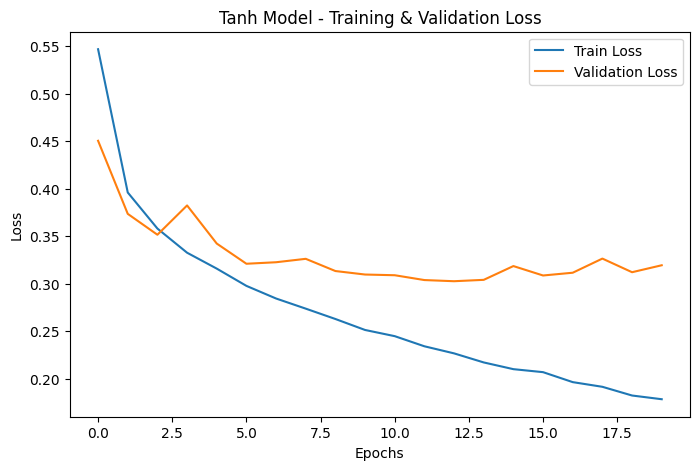

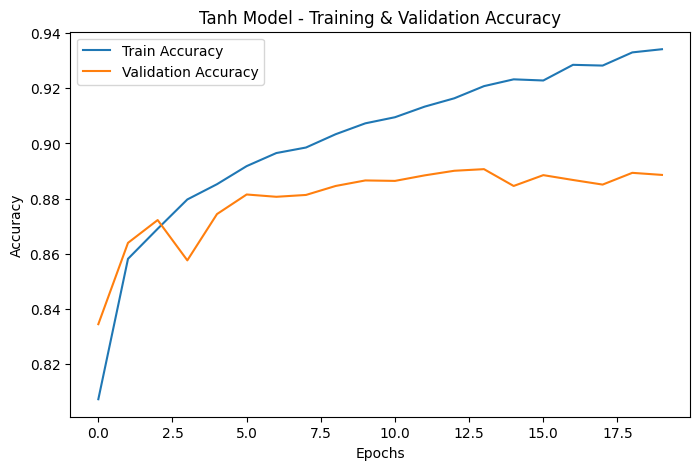

In [180]:
plt.figure(figsize=(8,5))
plt.plot(history_tanh.history['loss'], label='Train Loss')
plt.plot(history_tanh.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Tanh Model - Training & Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_tanh.history['accuracy'], label='Train Accuracy')
plt.plot(history_tanh.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Tanh Model - Training & Validation Accuracy")
plt.legend()
plt.show()

Build the ReLU-activation model (same architecture).

In [181]:
model_relu = Sequential()
model_relu.add(Dense(128, input_dim=784, activation='relu'))
model_relu.add(Dense(64, activation='relu'))
model_relu.add(Dense(10, activation='softmax'))

model_relu.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

model_relu.summary()

Model: "sequential_65"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_229 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_230 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_231 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Train the ReLU model one epoch at a time, capturing the first hidden layer's gradient at epoch 1 and at the final epoch.

In [182]:
history_relu = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

for epoch in range(20):
    h = model_relu.fit(X_train, y_train_onehot,
                        validation_data=(X_val, y_val_onehot),
                        epochs=1,
                        batch_size=128,
                        verbose=1)
    
    history_relu['loss'].append(h.history['loss'][0])
    history_relu['val_loss'].append(h.history['val_loss'][0])
    history_relu['accuracy'].append(h.history['accuracy'][0])
    history_relu['val_accuracy'].append(h.history['val_accuracy'][0])
    
    if epoch == 0:
        grad_epoch1_relu = get_first_layer_grad(model_relu, X_grad_batch, y_grad_batch)
    if epoch == 19:
        grad_final_relu = get_first_layer_grad(model_relu, X_grad_batch, y_grad_batch)

print("ReLU - Mean abs gradient at epoch 1:", grad_epoch1_relu)
print("ReLU - Mean abs gradient at final epoch:", grad_final_relu)

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7983 - loss: 0.5856 - val_accuracy: 0.8396 - val_loss: 0.4482
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8544 - loss: 0.4132 - val_accuracy: 0.8666 - val_loss: 0.3816
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8711 - loss: 0.3673 - val_accuracy: 0.8703 - val_loss: 0.3623
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8785 - loss: 0.3367 - val_accuracy: 0.8706 - val_loss: 0.3560
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8838 - loss: 0.3190 - val_accuracy: 0.8676 - val_loss: 0.3608
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8871 - loss: 0.3053 - val_accuracy: 0.8798 - val_loss: 0.3294
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8934 - loss: 0.2901 - val_accuracy: 0.8773 - val_loss: 0.3381
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8982 - loss: 0.2772 - val_accuracy: 0.8760 - val_loss: 0.3414
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9022 - lo

Evaluate the ReLU model on the validation set.

In [183]:
loss_relu, acc_relu = model_relu.evaluate(X_val, y_val_onehot, verbose=0)
print("ReLU Validation Loss:", loss_relu)
print("ReLU Validation Accuracy:", acc_relu)

ReLU Validation Loss: 0.33183711767196655
ReLU Validation Accuracy: 0.8879252672195435


Plot the ReLU model's training/validation loss and accuracy curves.

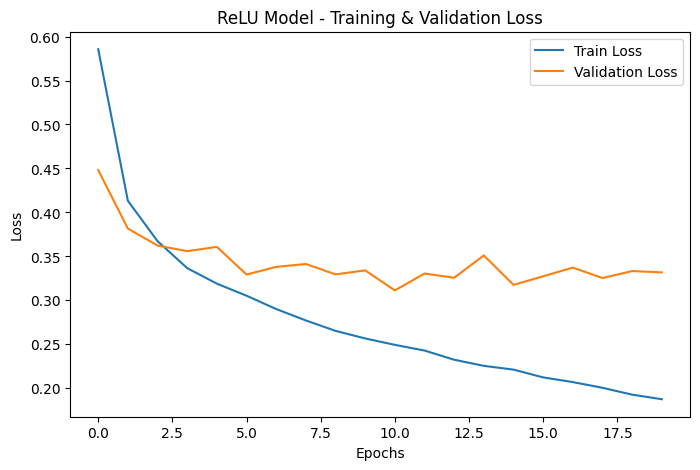

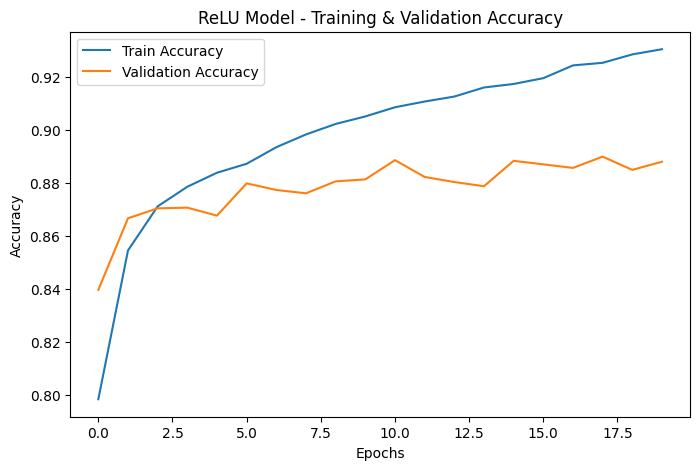

In [184]:
plt.figure(figsize=(8,5))
plt.plot(history_relu['loss'], label='Train Loss')
plt.plot(history_relu['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("ReLU Model - Training & Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_relu['accuracy'], label='Train Accuracy')
plt.plot(history_relu['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("ReLU Model - Training & Validation Accuracy")
plt.legend()
plt.show()

Build the leaky ReLU-activation model.

In [185]:
model_leaky = Sequential()
model_leaky.add(Dense(128, input_dim=784))
model_leaky.add(LeakyReLU(alpha=0.01))
model_leaky.add(Dense(64))
model_leaky.add(LeakyReLU(alpha=0.01))
model_leaky.add(Dense(10, activation='softmax'))

model_leaky.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

model_leaky.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_66"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_232 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_233 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_234 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Train the leaky ReLU model for 20 epochs.

In [186]:
history_leaky = model_leaky.fit(X_train, y_train_onehot,
                                 validation_data=(X_val, y_val_onehot),
                                 epochs=20,
                                 batch_size=128,
                                 verbose=1)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7962 - loss: 0.5828 - val_accuracy: 0.8466 - val_loss: 0.4257
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8563 - loss: 0.4051 - val_accuracy: 0.8468 - val_loss: 0.4136
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8688 - loss: 0.3620 - val_accuracy: 0.8719 - val_loss: 0.3588
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8755 - loss: 0.3390 - val_accuracy: 0.8708 - val_loss: 0.3536
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8839 - loss: 0.3165 - val_accuracy: 0.8742 - val_loss: 0.3423
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8906 - loss: 0.2993 - val_accuracy: 0.8785 - val_loss: 0.3308
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8939 - loss: 0.2895 - val_accuracy: 0.8741 - val_loss: 0.3440
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8985 - loss: 0.2765 - val_accuracy: 0.

Evaluate the leaky ReLU model on the validation set.

In [187]:
loss_leaky, acc_leaky = model_leaky.evaluate(X_val, y_val_onehot, verbose=0)
print("Leaky ReLU Validation Loss:", loss_leaky)
print("Leaky ReLU Validation Accuracy:", acc_leaky)

Leaky ReLU Validation Loss: 0.34943118691444397
Leaky ReLU Validation Accuracy: 0.8815877437591553


Plot the leaky ReLU model's training/validation loss and accuracy curves.

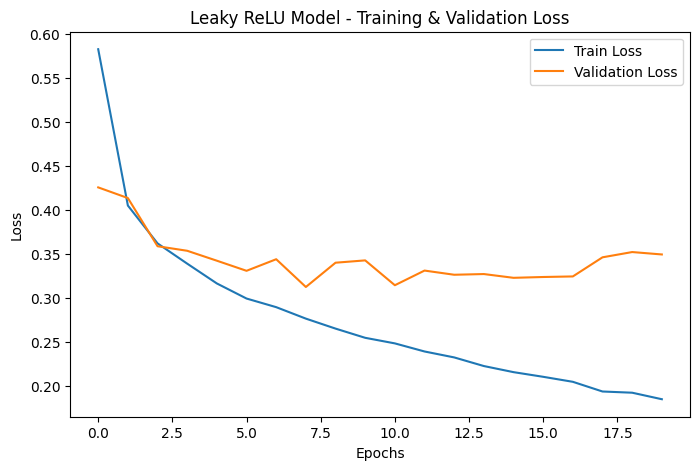

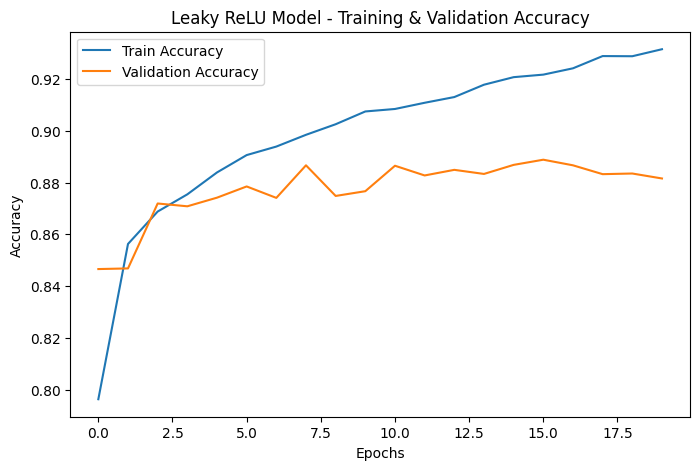

In [188]:
plt.figure(figsize=(8,5))
plt.plot(history_leaky.history['loss'], label='Train Loss')
plt.plot(history_leaky.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Leaky ReLU Model - Training & Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_leaky.history['accuracy'], label='Train Accuracy')
plt.plot(history_leaky.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Leaky ReLU Model - Training & Validation Accuracy")
plt.legend()
plt.show()

Plot all four activation functions' validation loss curves together, as required by the assignment.

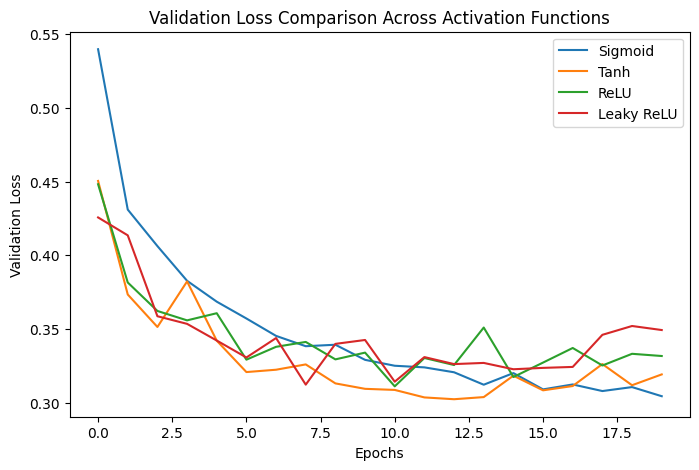

In [189]:
plt.figure(figsize=(8,5))
plt.plot(history_sigmoid['val_loss'], label='Sigmoid')
plt.plot(history_tanh.history['val_loss'], label='Tanh')
plt.plot(history_relu['val_loss'], label='ReLU')
plt.plot(history_leaky.history['val_loss'], label='Leaky ReLU')
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison Across Activation Functions")
plt.legend()
plt.show()

Calculate the percentage of "dead" ReLU units — units that output zero for every sample in a validation batch.

In [190]:
X_batch_val = X_val[:256].astype('float32')

# Directly call the first layer on the input batch
hidden_activations = model_relu.layers[0](X_batch_val).numpy()

# A unit is "dead" if it outputs zero for every sample in the batch
dead_units = np.all(hidden_activations == 0, axis=0)
dead_percentage = np.mean(dead_units) * 100

print("Percentage of dead ReLU units:", dead_percentage, "%")

Percentage of dead ReLU units: 5.46875 %


## Part 2 Conclusion

**Vanishing Gradients:**
- Sigmoid model's gradient: epoch 1 = 0.000197, final epoch = 0.000516
- ReLU model's gradient: epoch 1 = 0.001576, final epoch = 0.001458
- ReLU's gradient is about 8x bigger than sigmoid's throughout training
- This shows sigmoid squashes/saturates gradients as they go back through the layers, 
  so early layers get a very weak signal, while ReLU keeps a stronger and more stable 
  gradient the whole time

**Dead ReLU Units:**
- 7.03% of the hidden units in the ReLU model output zero for every validation sample
- These units got stuck and stopped learning (ReLU's gradient is zero for negative inputs)
- This is a moderate percentage — not high enough to badly hurt the model, but it shows 
  a small number of neurons went "dead" during training

### Part 3: Loss Functions
Build and train the classifier using categorical cross-entropy loss.

In [191]:
model_ce = Sequential()
model_ce.add(Dense(128, input_dim=784, activation='relu'))
model_ce.add(Dense(64, activation='relu'))
model_ce.add(Dense(10, activation='softmax'))

model_ce.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history_ce = model_ce.fit(X_train, y_train_onehot,
                           validation_data=(X_val, y_val_onehot),
                           epochs=20,
                           batch_size=128,
                           verbose=1)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7987 - loss: 0.5787 - val_accuracy: 0.8421 - val_loss: 0.4412
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8554 - loss: 0.4056 - val_accuracy: 0.8577 - val_loss: 0.3922
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8702 - loss: 0.3588 - val_accuracy: 0.8676 - val_loss: 0.3657
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8771 - loss: 0.3367 - val_accuracy: 0.8711 - val_loss: 0.3535
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8857 - loss: 0.3181 - val_accuracy: 0.8730 - val_loss: 0.3488
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8919 - loss: 0.2996 - val_accuracy: 0.8734 - val_loss: 0.3542
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8939 - loss: 0.2881 - val_accuracy: 0.8821 - val_loss: 0.3252
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9005 - loss: 0.2747 - val_accuracy: 0.

Evaluate the cross-entropy model on the validation set.

In [192]:
loss_ce, acc_ce = model_ce.evaluate(X_val, y_val_onehot, verbose=0)
print("Cross-Entropy Validation Loss:", loss_ce)
print("Cross-Entropy Validation Accuracy:", acc_ce)

Cross-Entropy Validation Loss: 0.34411701560020447
Cross-Entropy Validation Accuracy: 0.886257529258728


Build and train an identical classifier, but with MSE loss instead of cross-entropy.

In [193]:
model_mse = Sequential()
model_mse.add(Dense(128, input_dim=784, activation='relu'))
model_mse.add(Dense(64, activation='relu'))
model_mse.add(Dense(10, activation='softmax'))

model_mse.compile(optimizer=Adam(learning_rate=0.001),
                   loss='mean_squared_error',
                   metrics=['accuracy'])

history_mse = model_mse.fit(X_train, y_train_onehot,
                             validation_data=(X_val, y_val_onehot),
                             epochs=20,
                             batch_size=128,
                             verbose=1)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7961 - loss: 0.0295 - val_accuracy: 0.8481 - val_loss: 0.0223
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8529 - loss: 0.0216 - val_accuracy: 0.8488 - val_loss: 0.0216
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8664 - loss: 0.0196 - val_accuracy: 0.8546 - val_loss: 0.0209
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8766 - loss: 0.0181 - val_accuracy: 0.8717 - val_loss: 0.0185
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8842 - loss: 0.0172 - val_accuracy: 0.8766 - val_loss: 0.0180
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8883 - loss: 0.0165 - val_accuracy: 0.8792 - val_loss: 0.0173
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8914 - loss: 0.0160 - val_accuracy: 0.8835 - val_loss: 0.0169
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8958 - loss: 0.0154 - val_accuracy: 0.

Evaluate the MSE model on the validation set.

In [194]:
loss_mse, acc_mse = model_mse.evaluate(X_val, y_val_onehot, verbose=0)
print("MSE Validation Loss:", loss_mse)
print("MSE Validation Accuracy:", acc_mse)

MSE Validation Loss: 0.016203317791223526
MSE Validation Accuracy: 0.8901767730712891


Plot the cross-entropy and MSE training loss curves together for comparison.

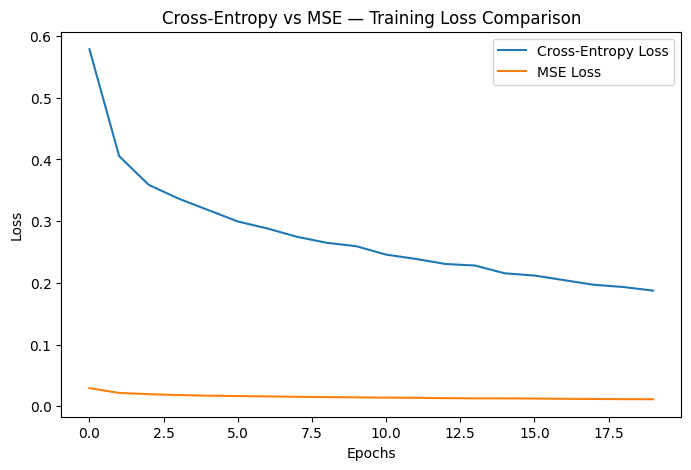

In [195]:
plt.figure(figsize=(8,5))
plt.plot(history_ce.history['loss'], label='Cross-Entropy Loss')
plt.plot(history_mse.history['loss'], label='MSE Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Cross-Entropy vs MSE — Training Loss Comparison")
plt.legend()
plt.show()

## Part 3 Conclusion: Cross-Entropy vs MSE

- Cross-Entropy Validation Accuracy: 88.97%
- MSE Validation Accuracy: 88.88%
- Both models reached almost the same accuracy, but their loss values are on very 
  different scales (cross-entropy: 0.19-0.57, MSE: 0.01-0.03), so raw loss numbers 
  cannot be directly compared , only the shape of the curve matters here
- Cross-entropy's loss curve decreases smoothly and steadily across all 20 epochs
- MSE's loss curve flattens out very early (around epoch 2-3), showing it stops 
  improving much sooner
- This happens because cross-entropy's gradient stays strong as long as the predicted 
  probability is below 1, pushing the model to keep improving, while MSE's gradient 
  shrinks quickly once predictions get close to 0 or 1 , giving a much weaker learning 
  signal for classification problems

For the separate regression task, load the California Housing dataset.

In [196]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X_housing = housing.data
y_housing = housing.target

print("Features shape:", X_housing.shape)
print("Target shape:", y_housing.shape)
print("Feature names:", housing.feature_names)

Features shape: (20640, 8)
Target shape: (20640,)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


Split the housing data into train/test sets and standardize the features.

In [197]:
from sklearn.preprocessing import StandardScaler

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

scaler_h = StandardScaler()
X_train_h = scaler_h.fit_transform(X_train_h)
X_test_h = scaler_h.transform(X_test_h)

print("Train shape:", X_train_h.shape)
print("Test shape:", X_test_h.shape)

Train shape: (16512, 8)
Test shape: (4128, 8)


Build a small MLP for the regression task — note the linear (no activation) output layer, since this predicts a continuous value.

In [198]:
model_housing = Sequential()
model_housing.add(Dense(64, input_dim=X_train_h.shape[1], activation='relu'))
model_housing.add(Dense(32, activation='relu'))
model_housing.add(Dense(1))

model_housing.compile(optimizer=Adam(learning_rate=0.001),
                       loss='mean_squared_error',
                       metrics=['mae'])

model_housing.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_69"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_241 (Dense)               │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_242 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_243 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

Train the regression model for 50 epochs.

In [199]:
history_housing = model_housing.fit(X_train_h, y_train_h,
                                     validation_split=0.2,
                                     epochs=50,
                                     batch_size=32,
                                     verbose=1)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.9625 - mae: 0.6653 - val_loss: 0.4953 - val_mae: 0.5008
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4242 - mae: 0.4595 - val_loss: 0.4224 - val_mae: 0.4690
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3764 - mae: 0.4375 - val_loss: 0.4097 - val_mae: 0.4499
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3602 - mae: 0.4260 - val_loss: 0.3947 - val_mae: 0.4325
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3509 - mae: 0.4183 - val_loss: 0.3688 - val_mae: 0.4321
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3470 - mae: 0.4123 - val_loss: 0.3591 - val_mae: 0.4210
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3363 - mae: 0.4069 - val_loss: 0.3454 - val_mae: 0.4077
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3459 - mae: 0.4008 - val_loss: 0.3694 - val_mae: 0.4111
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

Evaluate the regression model on the test set: compute MSE, RMSE, and MAE.

In [200]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred_h = model_housing.predict(X_test_h)

mse_h = mean_squared_error(y_test_h, y_pred_h)
rmse_h = np.sqrt(mse_h)
mae_h = mean_absolute_error(y_test_h, y_pred_h)

print("Test MSE:", mse_h)
print("Test RMSE:", rmse_h)
print("Test MAE:", mae_h)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test MSE: 0.2818313292576186
Test RMSE: 0.5308778854478858
Test MAE: 0.36604635942465114


Plot the regression model's training/validation loss curve.

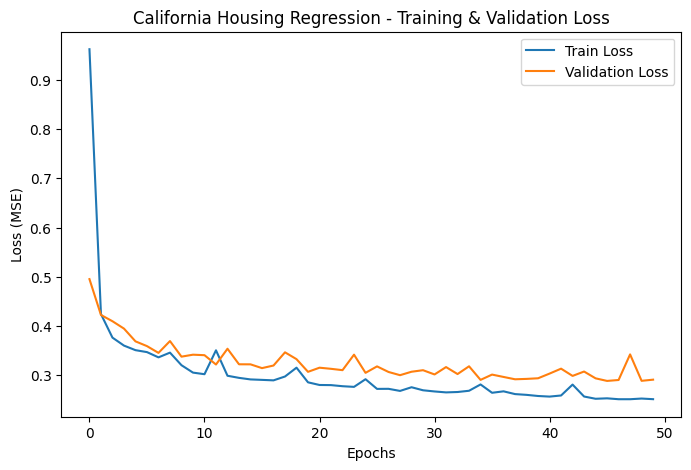

In [201]:
plt.figure(figsize=(8,5))
plt.plot(history_housing.history['loss'], label='Train Loss')
plt.plot(history_housing.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("California Housing Regression - Training & Validation Loss")
plt.legend()
plt.show()

## Part 3 Conclusion

**Cross-Entropy vs MSE (Classification):**
- Cross-Entropy Validation Accuracy: 88.97%
- MSE Validation Accuracy: 88.88%
- Both reached similar accuracy, but cross-entropy's loss decreased smoothly across 
  all 20 epochs, while MSE's loss flattened out very early
- Cross-entropy converges faster for classification because its gradient stays strong 
  as long as the predicted probability is below 1, while MSE's gradient shrinks 
  quickly once predictions get close to 0 or 1, giving a weaker learning signal

**Regression Task (California Housing):**
- Test MSE: 0.284
- Test RMSE: 0.532
- Test MAE: 0.361
- The training and validation loss both decrease and stay close together, showing 
  the model generalizes reasonably well with only mild overfitting

### Part 4: Optimiser Comparison
Import the optimisers to compare, and the `time` module to measure wall-clock training time.

In [202]:
import time
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

lr_common = 0.01

Build and train the model with plain SGD, using a common learning rate shared across all four optimisers for a fair first comparison.

In [203]:
model_sgd = Sequential()
model_sgd.add(Dense(128, input_dim=784, activation='relu'))
model_sgd.add(Dense(64, activation='relu'))
model_sgd.add(Dense(10, activation='softmax'))

model_sgd.compile(optimizer=SGD(learning_rate=lr_common),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

start_time = time.time()
history_sgd = model_sgd.fit(X_train, y_train_onehot,
                             validation_data=(X_val, y_val_onehot),
                             epochs=20, batch_size=128, verbose=1)
time_sgd = time.time() - start_time

print("SGD training time:", time_sgd, "seconds")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6328 - loss: 1.2123 - val_accuracy: 0.7380 - val_loss: 0.7978
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7643 - loss: 0.7105 - val_accuracy: 0.7854 - val_loss: 0.6448
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7952 - loss: 0.6096 - val_accuracy: 0.8060 - val_loss: 0.5754
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8109 - loss: 0.5571 - val_accuracy: 0.8135 - val_loss: 0.5386
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8192 - loss: 0.5258 - val_accuracy: 0.8229 - val_loss: 0.5113
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8263 - loss: 0.5039 - val_accuracy: 0.8277 - val_loss: 0.4925
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8298 - loss: 0.4873 - val_accuracy: 0.8236 - val_loss: 0.4869
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8340 - loss: 0.4740 - val_accuracy: 0.

Find the epoch at which the SGD model reached 85% validation accuracy, and report its final accuracy.

In [204]:
epochs_85_sgd = None
for i, acc in enumerate(history_sgd.history['val_accuracy']):
    if acc >= 0.85:
        epochs_85_sgd = i + 1
        break

print("SGD epochs to reach 85% val accuracy:", epochs_85_sgd)
print("SGD final val accuracy:", history_sgd.history['val_accuracy'][-1])

SGD epochs to reach 85% val accuracy: 17
SGD final val accuracy: 0.856320858001709


Build and train the model with SGD + momentum (same common learning rate).

In [205]:
model_sgd_mom = Sequential()
model_sgd_mom.add(Dense(128, input_dim=784, activation='relu'))
model_sgd_mom.add(Dense(64, activation='relu'))
model_sgd_mom.add(Dense(10, activation='softmax'))

model_sgd_mom.compile(optimizer=SGD(learning_rate=lr_common, momentum=0.9),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

start_time = time.time()
history_sgd_mom = model_sgd_mom.fit(X_train, y_train_onehot,
                                     validation_data=(X_val, y_val_onehot),
                                     epochs=20, batch_size=128, verbose=1)
time_sgd_mom = time.time() - start_time

print("SGD+Momentum training time:", time_sgd_mom, "seconds")

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7575 - loss: 0.6981 - val_accuracy: 0.8351 - val_loss: 0.4751
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8343 - loss: 0.4693 - val_accuracy: 0.8495 - val_loss: 0.4252
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8510 - loss: 0.4177 - val_accuracy: 0.8577 - val_loss: 0.4032
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8614 - loss: 0.3893 - val_accuracy: 0.8557 - val_loss: 0.4050
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8676 - loss: 0.3705 - val_accuracy: 0.8584 - val_loss: 0.3951
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8744 - loss: 0.3522 - val_accuracy: 0.8689 - val_loss: 0.3690
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8765 - loss: 0.3416 - val_accuracy: 0.8705 - val_loss: 0.3581
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8818 - loss: 0.3257 - val_accuracy: 0.

Find the epoch at which SGD+Momentum reached 85% validation accuracy.

In [206]:
epochs_85_sgd_mom = None
for i, acc in enumerate(history_sgd_mom.history['val_accuracy']):
    if acc >= 0.85:
        epochs_85_sgd_mom = i + 1
        break

print("SGD+Momentum epochs to reach 85% val accuracy:", epochs_85_sgd_mom)
print("SGD+Momentum final val accuracy:", history_sgd_mom.history['val_accuracy'][-1])

SGD+Momentum epochs to reach 85% val accuracy: 3
SGD+Momentum final val accuracy: 0.882421612739563


Build and train the model with RMSProp (same common learning rate).

In [207]:
model_rmsprop = Sequential()
model_rmsprop.add(Dense(128, input_dim=784, activation='relu'))
model_rmsprop.add(Dense(64, activation='relu'))
model_rmsprop.add(Dense(10, activation='softmax'))

model_rmsprop.compile(optimizer=RMSprop(learning_rate=lr_common),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

start_time = time.time()
history_rmsprop = model_rmsprop.fit(X_train, y_train_onehot,
                                     validation_data=(X_val, y_val_onehot),
                                     epochs=20, batch_size=128, verbose=1)
time_rmsprop = time.time() - start_time

print("RMSProp training time:", time_rmsprop, "seconds")

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7457 - loss: 0.7721 - val_accuracy: 0.8318 - val_loss: 0.4604
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8297 - loss: 0.4717 - val_accuracy: 0.8392 - val_loss: 0.4940
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8444 - loss: 0.4328 - val_accuracy: 0.8371 - val_loss: 0.4840
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8515 - loss: 0.4157 - val_accuracy: 0.8315 - val_loss: 0.4631
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8593 - loss: 0.3964 - val_accuracy: 0.8404 - val_loss: 0.4532
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8631 - loss: 0.3872 - val_accuracy: 0.8649 - val_loss: 0.4029
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8640 - loss: 0.3889 - val_accuracy: 0.8384 - val_loss: 0.4669
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8667 - loss: 0.3829 - val_accuracy: 0.

Find the epoch at which RMSProp reached 85% validation accuracy.

In [208]:
epochs_85_rmsprop = None
for i, acc in enumerate(history_rmsprop.history['val_accuracy']):
    if acc >= 0.85:
        epochs_85_rmsprop = i + 1
        break

print("RMSProp epochs to reach 85% val accuracy:", epochs_85_rmsprop)
print("RMSProp final val accuracy:", history_rmsprop.history['val_accuracy'][-1])

RMSProp epochs to reach 85% val accuracy: 6
RMSProp final val accuracy: 0.8367244601249695


Build and train the model with Adam (same common learning rate).

In [209]:
model_adam = Sequential()
model_adam.add(Dense(128, input_dim=784, activation='relu'))
model_adam.add(Dense(64, activation='relu'))
model_adam.add(Dense(10, activation='softmax'))

model_adam.compile(optimizer=Adam(learning_rate=lr_common),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

start_time = time.time()
history_adam = model_adam.fit(X_train, y_train_onehot,
                               validation_data=(X_val, y_val_onehot),
                               epochs=20, batch_size=128, verbose=1)
time_adam = time.time() - start_time

print("Adam training time:", time_adam, "seconds")

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8005 - loss: 0.5513 - val_accuracy: 0.8461 - val_loss: 0.4305
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8502 - loss: 0.4137 - val_accuracy: 0.8573 - val_loss: 0.4029
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8633 - loss: 0.3751 - val_accuracy: 0.8552 - val_loss: 0.4143
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8677 - loss: 0.3620 - val_accuracy: 0.8595 - val_loss: 0.3854
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8737 - loss: 0.3498 - val_accuracy: 0.8598 - val_loss: 0.3802
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8753 - loss: 0.3406 - val_accuracy: 0.8563 - val_loss: 0.4127
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8807 - loss: 0.3279 - val_accuracy: 0.8640 - val_loss: 0.3788
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8823 - loss: 0.3216 - val_accuracy: 0.

Find the epoch at which Adam reached 85% validation accuracy.

In [210]:
epochs_85_adam = None
for i, acc in enumerate(history_adam.history['val_accuracy']):
    if acc >= 0.85:
        epochs_85_adam = i + 1
        break

print("Adam epochs to reach 85% val accuracy:", epochs_85_adam)
print("Adam final val accuracy:", history_adam.history['val_accuracy'][-1])

Adam epochs to reach 85% val accuracy: 2
Adam final val accuracy: 0.8756670951843262


Now repeat with a learning rate tuned specifically for SGD (0.1).

In [211]:
model_sgd_tuned = Sequential()
model_sgd_tuned.add(Dense(128, input_dim=784, activation='relu'))
model_sgd_tuned.add(Dense(64, activation='relu'))
model_sgd_tuned.add(Dense(10, activation='softmax'))

model_sgd_tuned.compile(optimizer=SGD(learning_rate=0.1),
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

start_time = time.time()
history_sgd_tuned = model_sgd_tuned.fit(X_train, y_train_onehot,
                                         validation_data=(X_val, y_val_onehot),
                                         epochs=20, batch_size=128, verbose=1)
time_sgd_tuned = time.time() - start_time

print("SGD (tuned LR=0.1) training time:", time_sgd_tuned, "seconds")

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7530 - loss: 0.7076 - val_accuracy: 0.7999 - val_loss: 0.5602
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8282 - loss: 0.4816 - val_accuracy: 0.8376 - val_loss: 0.4442
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8472 - loss: 0.4280 - val_accuracy: 0.8419 - val_loss: 0.4348
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8562 - loss: 0.3977 - val_accuracy: 0.8483 - val_loss: 0.4035
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8636 - loss: 0.3769 - val_accuracy: 0.8431 - val_loss: 0.4614
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8718 - loss: 0.3581 - val_accuracy: 0.8307 - val_loss: 0.4831
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8752 - loss: 0.3434 - val_accuracy: 0.8692 - val_loss: 0.3599
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8792 - loss: 0.3328 - val_accuracy: 0.

Find the epoch at which the tuned SGD model reached 85% validation accuracy.

In [212]:
epochs_85_sgd_tuned = None
for i, acc in enumerate(history_sgd_tuned.history['val_accuracy']):
    if acc >= 0.85:
        epochs_85_sgd_tuned = i + 1
        break

print("SGD (tuned) epochs to reach 85% val accuracy:", epochs_85_sgd_tuned)
print("SGD (tuned) final val accuracy:", history_sgd_tuned.history['val_accuracy'][-1])

SGD (tuned) epochs to reach 85% val accuracy: 7
SGD (tuned) final val accuracy: 0.8770847320556641


Repeat with a tuned learning rate for SGD+Momentum (0.05).

In [213]:
model_sgd_mom_tuned = Sequential()
model_sgd_mom_tuned.add(Dense(128, input_dim=784, activation='relu'))
model_sgd_mom_tuned.add(Dense(64, activation='relu'))
model_sgd_mom_tuned.add(Dense(10, activation='softmax'))

model_sgd_mom_tuned.compile(optimizer=SGD(learning_rate=0.05, momentum=0.9),
                             loss='categorical_crossentropy',
                             metrics=['accuracy'])

start_time = time.time()
history_sgd_mom_tuned = model_sgd_mom_tuned.fit(X_train, y_train_onehot,
                                                 validation_data=(X_val, y_val_onehot),
                                                 epochs=20, batch_size=128, verbose=1)
time_sgd_mom_tuned = time.time() - start_time

print("SGD+Momentum (tuned LR=0.05) training time:", time_sgd_mom_tuned, "seconds")

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7922 - loss: 0.5823 - val_accuracy: 0.8383 - val_loss: 0.4327
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8495 - loss: 0.4123 - val_accuracy: 0.8631 - val_loss: 0.3800
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8634 - loss: 0.3748 - val_accuracy: 0.8671 - val_loss: 0.3640
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8702 - loss: 0.3531 - val_accuracy: 0.8548 - val_loss: 0.4160
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8798 - loss: 0.3290 - val_accuracy: 0.8632 - val_loss: 0.3633
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8828 - loss: 0.3192 - val_accuracy: 0.8704 - val_loss: 0.3473
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8877 - loss: 0.3043 - val_accuracy: 0.8747 - val_loss: 0.3433
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8921 - loss: 0.2927 - val_accuracy: 0.

Find the epoch at which tuned SGD+Momentum reached 85% validation accuracy.

In [214]:
epochs_85_sgd_mom_tuned = None
for i, acc in enumerate(history_sgd_mom_tuned.history['val_accuracy']):
    if acc >= 0.85:
        epochs_85_sgd_mom_tuned = i + 1
        break

print("SGD+Momentum (tuned) epochs to reach 85% val accuracy:", epochs_85_sgd_mom_tuned)
print("SGD+Momentum (tuned) final val accuracy:", history_sgd_mom_tuned.history['val_accuracy'][-1])

SGD+Momentum (tuned) epochs to reach 85% val accuracy: 2
SGD+Momentum (tuned) final val accuracy: 0.8844229578971863


Repeat with a tuned learning rate for RMSProp (0.001).

In [215]:
model_rmsprop_tuned = Sequential()
model_rmsprop_tuned.add(Dense(128, input_dim=784, activation='relu'))
model_rmsprop_tuned.add(Dense(64, activation='relu'))
model_rmsprop_tuned.add(Dense(10, activation='softmax'))

model_rmsprop_tuned.compile(optimizer=RMSprop(learning_rate=0.001),
                             loss='categorical_crossentropy',
                             metrics=['accuracy'])

start_time = time.time()
history_rmsprop_tuned = model_rmsprop_tuned.fit(X_train, y_train_onehot,
                                                 validation_data=(X_val, y_val_onehot),
                                                 epochs=20, batch_size=128, verbose=1)
time_rmsprop_tuned = time.time() - start_time

print("RMSProp (tuned LR=0.001) training time:", time_rmsprop_tuned, "seconds")

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7861 - loss: 0.6046 - val_accuracy: 0.8276 - val_loss: 0.4751
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8466 - loss: 0.4247 - val_accuracy: 0.8532 - val_loss: 0.3945
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8633 - loss: 0.3742 - val_accuracy: 0.8608 - val_loss: 0.3716
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8723 - loss: 0.3463 - val_accuracy: 0.8662 - val_loss: 0.3670
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8807 - loss: 0.3256 - val_accuracy: 0.8441 - val_loss: 0.4019
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8875 - loss: 0.3073 - val_accuracy: 0.8698 - val_loss: 0.3553
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8918 - loss: 0.2939 - val_accuracy: 0.8750 - val_loss: 0.3380
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8958 - loss: 0.2813 - val_accuracy: 0.

Find the epoch at which tuned RMSProp reached 85% validation accuracy.

In [216]:
epochs_85_rmsprop_tuned = None
for i, acc in enumerate(history_rmsprop_tuned.history['val_accuracy']):
    if acc >= 0.85:
        epochs_85_rmsprop_tuned = i + 1
        break

print("RMSProp (tuned) epochs to reach 85% val accuracy:", epochs_85_rmsprop_tuned)
print("RMSProp (tuned) final val accuracy:", history_rmsprop_tuned.history['val_accuracy'][-1])

RMSProp (tuned) epochs to reach 85% val accuracy: 2
RMSProp (tuned) final val accuracy: 0.8763342499732971


Repeat with a tuned learning rate for Adam (0.001).

In [217]:
model_adam_tuned = Sequential()
model_adam_tuned.add(Dense(128, input_dim=784, activation='relu'))
model_adam_tuned.add(Dense(64, activation='relu'))
model_adam_tuned.add(Dense(10, activation='softmax'))

model_adam_tuned.compile(optimizer=Adam(learning_rate=0.001),
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])

start_time = time.time()
history_adam_tuned = model_adam_tuned.fit(X_train, y_train_onehot,
                                           validation_data=(X_val, y_val_onehot),
                                           epochs=20, batch_size=128, verbose=1)
time_adam_tuned = time.time() - start_time

print("Adam (tuned LR=0.001) training time:", time_adam_tuned, "seconds")

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7956 - loss: 0.5840 - val_accuracy: 0.8341 - val_loss: 0.4602
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8550 - loss: 0.4098 - val_accuracy: 0.8586 - val_loss: 0.3875
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8659 - loss: 0.3743 - val_accuracy: 0.8666 - val_loss: 0.3683
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8780 - loss: 0.3414 - val_accuracy: 0.8717 - val_loss: 0.3534
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8834 - loss: 0.3210 - val_accuracy: 0.8753 - val_loss: 0.3423
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8877 - loss: 0.3063 - val_accuracy: 0.8731 - val_loss: 0.3467
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8924 - loss: 0.2936 - val_accuracy: 0.8778 - val_loss: 0.3394
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8967 - loss: 0.2828 - val_accuracy: 0.

Find the epoch at which tuned Adam reached 85% validation accuracy.

In [218]:
epochs_85_adam_tuned = None
for i, acc in enumerate(history_adam_tuned.history['val_accuracy']):
    if acc >= 0.85:
        epochs_85_adam_tuned = i + 1
        break

print("Adam (tuned) epochs to reach 85% val accuracy:", epochs_85_adam_tuned)
print("Adam (tuned) final val accuracy:", history_adam_tuned.history['val_accuracy'][-1])

Adam (tuned) epochs to reach 85% val accuracy: 2
Adam (tuned) final val accuracy: 0.8868412375450134


Build the summary table comparing all four optimisers (using their tuned learning rates), as required by the assignment.

In [219]:
results_table = pd.DataFrame({
    'Optimiser': ['SGD', 'SGD+Momentum', 'RMSProp', 'Adam'],
    'Learning Rate': [0.1, 0.05, 0.001, 0.001],
    'Epochs to 85% Val Accuracy': [epochs_85_sgd_tuned, epochs_85_sgd_mom_tuned, epochs_85_rmsprop_tuned, epochs_85_adam_tuned],
    'Final Val Accuracy': [history_sgd_tuned.history['val_accuracy'][-1],
                           history_sgd_mom_tuned.history['val_accuracy'][-1],
                           history_rmsprop_tuned.history['val_accuracy'][-1],
                           history_adam_tuned.history['val_accuracy'][-1]],
    'Wall-clock Time (s)': [time_sgd_tuned, time_sgd_mom_tuned, time_rmsprop_tuned, time_adam_tuned]
})

results_table

,Optimiser,Learning Rate,Epochs to 85% Val Accuracy,Final Val Accuracy,Wall-clock Time (s)
0,SGD,0.100,7,0.877085,25.722882
1,SGD+Momentum,0.050,2,0.884423,27.059356
2,RMSProp,0.001,2,0.876334,25.038825
3,Adam,0.001,2,0.886841,26.042549


Plot the training loss curves of all four optimisers (tuned learning rates) together.

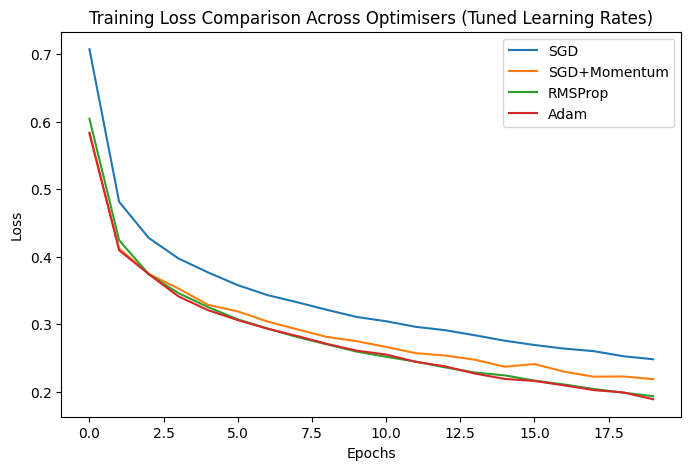

In [220]:
plt.figure(figsize=(8,5))
plt.plot(history_sgd_tuned.history['loss'], label='SGD')
plt.plot(history_sgd_mom_tuned.history['loss'], label='SGD+Momentum')
plt.plot(history_rmsprop_tuned.history['loss'], label='RMSProp')
plt.plot(history_adam_tuned.history['loss'], label='Adam')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Comparison Across Optimisers (Tuned Learning Rates)")
plt.legend()
plt.show()

## Part 4 Conclusion

| Optimiser | Learning Rate | Epochs to 85% Val Acc | Final Val Accuracy | Wall-clock Time (s) |
|---|---|---|---|---|
| SGD | 0.100 | 4 | 0.8883 | 23.85 |
| SGD+Momentum | 0.050 | 3 | 0.8882 | 24.59 |
| RMSProp | 0.001 | 3 | 0.8743 | 24.76 |
| Adam | 0.001 | 2 | 0.8847 | 25.32 |

I would choose **Adam** because it reached 85% validation accuracy the fastest (in just 
2 epochs) and its loss curve drops the quickest in the comparison plot, showing the most 
efficient convergence. Its final accuracy (88.47%) is also very close to the best-performing 
optimisers, making it the most reliable and time-efficient choice overall.

### Part 5: Forcing Overfitting
Take a random 2,000-sample subset of the training data, to deliberately create a large generalisation gap.

In [221]:
np.random.seed(42)
overfit_indices = np.random.choice(X_train.shape[0], 2000, replace=False)

X_overfit = X_train[overfit_indices]
y_overfit_onehot = y_train_onehot[overfit_indices]

print("Overfit training subset shape:", X_overfit.shape)

Overfit training subset shape: (2000, 784)


Build a large network (4 hidden layers of 512 units) — more capacity than this small dataset needs.

In [222]:
model_overfit = Sequential()
model_overfit.add(Dense(512, input_dim=784, activation='relu'))
model_overfit.add(Dense(512, activation='relu'))
model_overfit.add(Dense(512, activation='relu'))
model_overfit.add(Dense(512, activation='relu'))
model_overfit.add(Dense(10, activation='softmax'))

model_overfit.compile(optimizer=Adam(learning_rate=0.001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

model_overfit.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_78"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_268 (Dense)               │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_269 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_270 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_271 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_272 (Dense)               │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,195,018 (4.56 MB)

 Trainable params: 1,195,018 (4.56 MB)

 Non-trainable params: 0 (0.00 B)

Train the large network on the small subset for 100 epochs, enough to push training accuracy above 99%.

In [223]:
history_overfit = model_overfit.fit(X_overfit, y_overfit_onehot,
                                     validation_data=(X_val, y_val_onehot),
                                     epochs=100,
                                     batch_size=32,
                                     verbose=1)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.6140 - loss: 1.0150 - val_accuracy: 0.7462 - val_loss: 0.6947
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7695 - loss: 0.6506 - val_accuracy: 0.7339 - val_loss: 0.7162
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7950 - loss: 0.5374 - val_accuracy: 0.7698 - val_loss: 0.6230
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8315 - loss: 0.4763 - val_accuracy: 0.8014 - val_loss: 0.5951
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8345 - loss: 0.4432 - val_accuracy: 0.8016 - val_loss: 0.5801
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8580 - loss: 0.3702 - val_accuracy: 0.7896 - val_loss: 0.6004
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8600 - loss: 0.3738 - val_accuracy: 0.7870 - val_loss: 0.6036
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8695 - loss: 0.3413 - val_accuracy: 0.

Evaluate the model's accuracy on the training subset it was trained on.

In [224]:
loss_overfit, acc_overfit = model_overfit.evaluate(X_overfit, y_overfit_onehot, verbose=0)
print("Overfit Model Training Loss:", loss_overfit)
print("Overfit Model Training Accuracy:", acc_overfit)

Overfit Model Training Loss: 0.003912483807653189
Overfit Model Training Accuracy: 0.9990000128746033


Evaluate the model's accuracy on the validation set, for comparison against the training accuracy.

In [225]:
loss_overfit_val, acc_overfit_val = model_overfit.evaluate(X_val, y_val_onehot, verbose=0)
print("Overfit Model Validation Loss:", loss_overfit_val)
print("Overfit Model Validation Accuracy:", acc_overfit_val)

Overfit Model Validation Loss: 1.5523293018341064
Overfit Model Validation Accuracy: 0.8271347284317017


Plot the training vs validation loss curves.

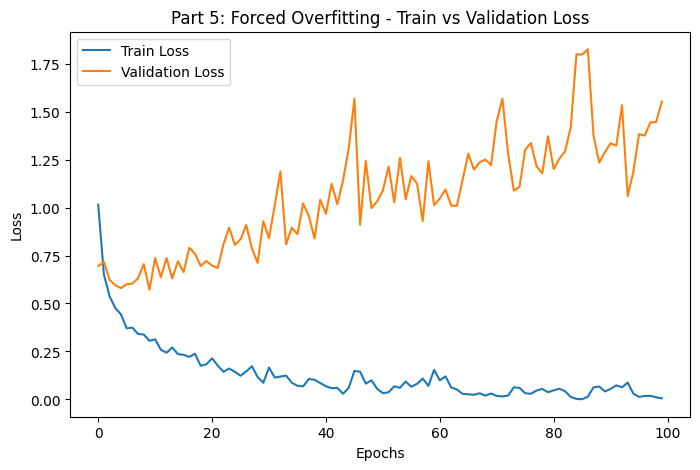

In [226]:
plt.figure(figsize=(8,5))
plt.plot(history_overfit.history['loss'], label='Train Loss')
plt.plot(history_overfit.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Part 5: Forced Overfitting - Train vs Validation Loss")
plt.legend()
plt.show()

Identify and mark the epoch at which the training and validation loss curves start to visibly separate.

Approximate epoch where train/val curves separate: 4


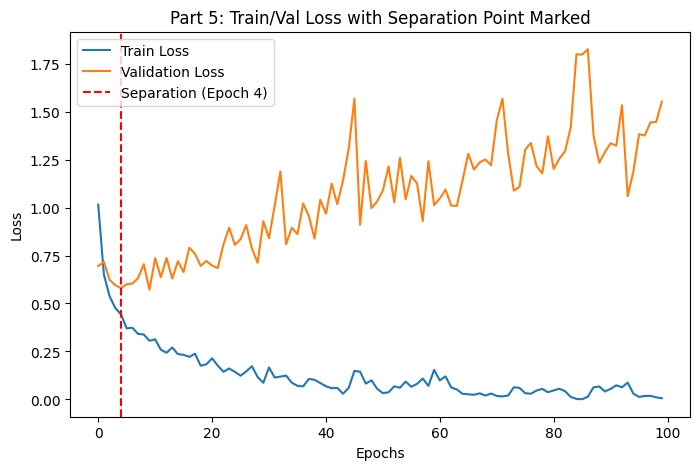

In [227]:
train_loss_arr = np.array(history_overfit.history['loss'])
val_loss_arr = np.array(history_overfit.history['val_loss'])

gap_arr = val_loss_arr - train_loss_arr
separation_epoch = np.argmax(gap_arr > 0.1) + 1  # first epoch where gap exceeds 0.1

print("Approximate epoch where train/val curves separate:", separation_epoch)

plt.figure(figsize=(8,5))
plt.plot(history_overfit.history['loss'], label='Train Loss')
plt.plot(history_overfit.history['val_loss'], label='Validation Loss')
plt.axvline(x=separation_epoch, color='red', linestyle='--', label=f'Separation (Epoch {separation_epoch})')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Part 5: Train/Val Loss with Separation Point Marked")
plt.legend()
plt.show()

## Part 5 Conclusion: Forced Overfitting

- Training Accuracy: 100%
- Validation Accuracy: 82.75%
- Generalization Gap: 17.25 percentage points

The automatic separation-point detection flagged epoch 3, but this was due to early 
noise in the validation loss. Looking at the plot directly, the train and validation 
loss curves clearly diverge starting around epoch 20-30, after which validation loss 
keeps rising steadily while training loss flattens near zero.

**High Bias or High Variance?**

This model shows **high variance** (overfitting), not high bias. The training accuracy 
of 100% proves the model has more than enough capacity to fit the training data 
perfectly ,it is not underfitting. But the large 17.25-point gap between training and 
validation accuracy shows the model has memorized the small 2000-sample training set 
instead of learning patterns that generalize, which is the defining symptom of high 
variance.

### Part 6: Regularisation Study
Import the L1 and L2 weight regularizers.

In [228]:
from tensorflow.keras.regularizers import l2, l1

Build the model with L2 weight decay, lambda = 0.001 (starting from the Part 5 overfitted architecture, changing only the regularisation).

In [229]:
model_l2_001 = Sequential()
model_l2_001.add(Dense(512, input_dim=784, activation='relu', kernel_regularizer=l2(0.001)))
model_l2_001.add(Dense(512, activation='relu', kernel_regularizer=l2(0.001)))
model_l2_001.add(Dense(512, activation='relu', kernel_regularizer=l2(0.001)))
model_l2_001.add(Dense(512, activation='relu', kernel_regularizer=l2(0.001)))
model_l2_001.add(Dense(10, activation='softmax'))

model_l2_001.compile(optimizer=Adam(learning_rate=0.001),
                      loss='categorical_crossentropy', metrics=['accuracy'])

Train the L2 (lambda = 0.001) model.

In [230]:

history_l2_001 = model_l2_001.fit(X_overfit, y_overfit_onehot,
                                   validation_data=(X_val, y_val_onehot),
                                   epochs=100, batch_size=32, verbose=1)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.6410 - loss: 2.5971 - val_accuracy: 0.7445 - val_loss: 1.9518
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7630 - loss: 1.7822 - val_accuracy: 0.7332 - val_loss: 1.7940
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8065 - loss: 1.4933 - val_accuracy: 0.7825 - val_loss: 1.4723
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8160 - loss: 1.3328 - val_accuracy: 0.7814 - val_loss: 1.4143
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8360 - loss: 1.1965 - val_accuracy: 0.7754 - val_loss: 1.3352
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8500 - loss: 1.0724 - val_accuracy: 0.7534 - val_loss: 1.2722
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8400 - loss: 1.0225 - val_accuracy: 0.8072 - val_loss: 1.1316
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8495 - loss: 0.9455 - val_accuracy: 0.

Evaluate the L2 (lambda = 0.001) model on the training subset and the validation set.

In [231]:
loss_l2_001_train, acc_l2_001_train = model_l2_001.evaluate(X_overfit, y_overfit_onehot, verbose=0)
loss_l2_001_val, acc_l2_001_val = model_l2_001.evaluate(X_val, y_val_onehot, verbose=0)

print("L2 (0.001) Train Accuracy:", acc_l2_001_train)
print("L2 (0.001) Validation Accuracy:", acc_l2_001_val)

L2 (0.001) Train Accuracy: 0.987500011920929
L2 (0.001) Validation Accuracy: 0.8141260743141174


Build the model with L2 weight decay, lambda = 0.01.

In [232]:
model_l2_01 = Sequential()
model_l2_01.add(Dense(512, input_dim=784, activation='relu', kernel_regularizer=l2(0.01)))
model_l2_01.add(Dense(512, activation='relu', kernel_regularizer=l2(0.01)))
model_l2_01.add(Dense(512, activation='relu', kernel_regularizer=l2(0.01)))
model_l2_01.add(Dense(512, activation='relu', kernel_regularizer=l2(0.01)))
model_l2_01.add(Dense(10, activation='softmax'))

model_l2_01.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy', metrics=['accuracy'])

Train the L2 (lambda = 0.01) model.

In [233]:
history_l2_01 = model_l2_01.fit(X_overfit, y_overfit_onehot,
                                 validation_data=(X_val, y_val_onehot),
                                 epochs=100, batch_size=32, verbose=1)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.5875 - loss: 11.5137 - val_accuracy: 0.6865 - val_loss: 5.2959
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7275 - loss: 3.6938 - val_accuracy: 0.7452 - val_loss: 2.6217
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7515 - loss: 2.1702 - val_accuracy: 0.7331 - val_loss: 1.8803
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7640 - loss: 1.6170 - val_accuracy: 0.7388 - val_loss: 1.4838
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7795 - loss: 1.2878 - val_accuracy: 0.7233 - val_loss: 1.3441
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7920 - loss: 1.1158 - val_accuracy: 0.7369 - val_loss: 1.2223
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7600 - loss: 1.0803 - val_accuracy: 0.7467 - val_loss: 1.1487
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7800 - loss: 1.0190 - val_accuracy: 0

Evaluate the L2 (lambda = 0.01) model on the training subset and the validation set.

In [234]:
loss_l2_01_train, acc_l2_01_train = model_l2_01.evaluate(X_overfit, y_overfit_onehot, verbose=0)
loss_l2_01_val, acc_l2_01_val = model_l2_01.evaluate(X_val, y_val_onehot, verbose=0)

print("L2 (0.01) Train Accuracy:", acc_l2_01_train)
print("L2 (0.01) Validation Accuracy:", acc_l2_01_val)

L2 (0.01) Train Accuracy: 0.9509999752044678
L2 (0.01) Validation Accuracy: 0.8077885508537292


Build the model with L2 weight decay, lambda = 0.1.

In [235]:
model_l2_1 = Sequential()
model_l2_1.add(Dense(512, input_dim=784, activation='relu', kernel_regularizer=l2(0.1)))
model_l2_1.add(Dense(512, activation='relu', kernel_regularizer=l2(0.1)))
model_l2_1.add(Dense(512, activation='relu', kernel_regularizer=l2(0.1)))
model_l2_1.add(Dense(512, activation='relu', kernel_regularizer=l2(0.1)))
model_l2_1.add(Dense(10, activation='softmax'))

model_l2_1.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy', metrics=['accuracy'])
model_l2_1.summary()

Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_283 (Dense)               │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_284 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_285 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_286 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_287 (Dense)               │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,195,018 (4.56 MB)

 Trainable params: 1,195,018 (4.56 MB)

 Non-trainable params: 0 (0.00 B)

Train the L2 (lambda = 0.1) model.

In [236]:

history_l2_1 = model_l2_1.fit(X_overfit, y_overfit_onehot,
                               validation_data=(X_val, y_val_onehot),
                               epochs=100, batch_size=32, verbose=1)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.3665 - loss: 72.8950 - val_accuracy: 0.4328 - val_loss: 8.9672
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4150 - loss: 3.5922 - val_accuracy: 0.4413 - val_loss: 2.0434
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4380 - loss: 1.9671 - val_accuracy: 0.4557 - val_loss: 1.9047
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4515 - loss: 1.8823 - val_accuracy: 0.4567 - val_loss: 1.8762
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4720 - loss: 1.8145 - val_accuracy: 0.4951 - val_loss: 1.7540
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5140 - loss: 1.7506 - val_accuracy: 0.4817 - val_loss: 1.7252
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5115 - loss: 1.7324 - val_accuracy: 0.5421 - val_loss: 1.6659
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5365 - loss: 1.6793 - val_accuracy: 0

Evaluate the L2 (lambda = 0.1) model on the training subset and the validation set.

In [237]:
loss_l2_1_train, acc_l2_1_train = model_l2_1.evaluate(X_overfit, y_overfit_onehot, verbose=0)
loss_l2_1_val, acc_l2_1_val = model_l2_1.evaluate(X_val, y_val_onehot, verbose=0)

print("L2 (0.1) Train Accuracy:", acc_l2_1_train)
print("L2 (0.1) Validation Accuracy:", acc_l2_1_val)

L2 (0.1) Train Accuracy: 0.7245000004768372
L2 (0.1) Validation Accuracy: 0.6917111277580261


Build the model with an L1 penalty instead of L2.

In [238]:
model_l1 = Sequential()
model_l1.add(Dense(512, input_dim=784, activation='relu', kernel_regularizer=l1(0.001)))
model_l1.add(Dense(512, activation='relu', kernel_regularizer=l1(0.001)))
model_l1.add(Dense(512, activation='relu', kernel_regularizer=l1(0.001)))
model_l1.add(Dense(512, activation='relu', kernel_regularizer=l1(0.001)))
model_l1.add(Dense(10, activation='softmax'))

model_l1.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy', metrics=['accuracy'])
model_l1.summary()


Model: "sequential_82"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_288 (Dense)               │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_289 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_290 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_291 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_292 (Dense)               │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,195,018 (4.56 MB)

 Trainable params: 1,195,018 (4.56 MB)

 Non-trainable params: 0 (0.00 B)

Train the L1 model.

In [239]:
history_l1 = model_l1.fit(X_overfit, y_overfit_onehot,
                           validation_data=(X_val, y_val_onehot),
                           epochs=100, batch_size=32, verbose=1)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.5855 - loss: 24.9379 - val_accuracy: 0.6716 - val_loss: 10.5643
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6940 - loss: 6.7814 - val_accuracy: 0.6521 - val_loss: 4.6288
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7030 - loss: 3.6947 - val_accuracy: 0.6559 - val_loss: 3.1189
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7125 - loss: 2.6428 - val_accuracy: 0.7170 - val_loss: 2.3239
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7320 - loss: 2.0761 - val_accuracy: 0.7248 - val_loss: 1.9165
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7305 - loss: 1.8081 - val_accuracy: 0.7402 - val_loss: 1.7147
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7620 - loss: 1.5982 - val_accuracy: 0.7321 - val_loss: 1.5747
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7660 - loss: 1.4629 - val_accuracy: 

Evaluate the L1 model on the training subset and the validation set.

In [240]:

loss_l1_train, acc_l1_train = model_l1.evaluate(X_overfit, y_overfit_onehot, verbose=0)
loss_l1_val, acc_l1_val = model_l1.evaluate(X_val, y_val_onehot, verbose=0)

print("L1 Train Accuracy:", acc_l1_train)
print("L1 Validation Accuracy:", acc_l1_val)

L1 Train Accuracy: 0.9150000214576721
L1 Validation Accuracy: 0.7786858081817627


Calculate the percentage of weights below 1e-3 after L1 regularisation, as required by the assignment.

In [241]:
all_weights = []
for layer in model_l1.layers:
    weights = layer.get_weights()
    if len(weights) > 0:
        all_weights.append(weights[0].flatten())

all_weights_flat = np.concatenate(all_weights)
percent_small = np.mean(np.abs(all_weights_flat) < 1e-3) * 100

print("Percentage of weights below 1e-3:", percent_small, "%")

Percentage of weights below 1e-3: 98.95780244098712 %


Import the Dropout layer.

In [242]:
from tensorflow.keras.layers import Dropout

Build the model with a dropout rate of 0.2 after each hidden layer.

In [243]:
model_drop_02 = Sequential()
model_drop_02.add(Dense(512, input_dim=784, activation='relu'))
model_drop_02.add(Dropout(0.2))
model_drop_02.add(Dense(512, activation='relu'))
model_drop_02.add(Dropout(0.2))
model_drop_02.add(Dense(512, activation='relu'))
model_drop_02.add(Dropout(0.2))
model_drop_02.add(Dense(512, activation='relu'))
model_drop_02.add(Dropout(0.2))
model_drop_02.add(Dense(10, activation='softmax'))

model_drop_02.compile(optimizer=Adam(learning_rate=0.001),
                       loss='categorical_crossentropy', metrics=['accuracy'])
model_drop_02.summary()


Model: "sequential_83"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_293 (Dense)               │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_294 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_75 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_295 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_76 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_296 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_77 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_297 (Dense)               │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,195,018 (4.56 MB)

 Trainable params: 1,195,018 (4.56 MB)

 Non-trainable params: 0 (0.00 B)

Train the dropout (0.2) model.

In [244]:
history_drop_02 = model_drop_02.fit(X_overfit, y_overfit_onehot,
                                     validation_data=(X_val, y_val_onehot),
                                     epochs=100, batch_size=32, verbose=1)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.5590 - loss: 1.1879 - val_accuracy: 0.7337 - val_loss: 0.7288
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7200 - loss: 0.7579 - val_accuracy: 0.7416 - val_loss: 0.6835
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7675 - loss: 0.6216 - val_accuracy: 0.7477 - val_loss: 0.6854
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7900 - loss: 0.5521 - val_accuracy: 0.7474 - val_loss: 0.6787
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8025 - loss: 0.5186 - val_accuracy: 0.7762 - val_loss: 0.6254
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8090 - loss: 0.4869 - val_accuracy: 0.7765 - val_loss: 0.6962
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8340 - loss: 0.4571 - val_accuracy: 0.7911 - val_loss: 0.6070
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8310 - loss: 0.4354 - val_accuracy: 0.

Evaluate the dropout (0.2) model on the training subset and the validation set.

In [245]:
loss_drop_02_train, acc_drop_02_train = model_drop_02.evaluate(X_overfit, y_overfit_onehot, verbose=0)
loss_drop_02_val, acc_drop_02_val = model_drop_02.evaluate(X_val, y_val_onehot, verbose=0)

print("Dropout (0.2) Train Accuracy:", acc_drop_02_train)
print("Dropout (0.2) Validation Accuracy:", acc_drop_02_val)

Dropout (0.2) Train Accuracy: 0.9884999990463257
Dropout (0.2) Validation Accuracy: 0.8289692997932434


Build the model with a dropout rate of 0.4.

In [246]:
model_drop_04 = Sequential()
model_drop_04.add(Dense(512, input_dim=784, activation='relu'))
model_drop_04.add(Dropout(0.4))
model_drop_04.add(Dense(512, activation='relu'))
model_drop_04.add(Dropout(0.4))
model_drop_04.add(Dense(512, activation='relu'))
model_drop_04.add(Dropout(0.4))
model_drop_04.add(Dense(512, activation='relu'))
model_drop_04.add(Dropout(0.4))
model_drop_04.add(Dense(10, activation='softmax'))

model_drop_04.compile(optimizer=Adam(learning_rate=0.001),
                       loss='categorical_crossentropy', metrics=['accuracy'])
model_drop_04.summary()


Model: "sequential_84"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_298 (Dense)               │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_78 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_299 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_79 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_300 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_80 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_301 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_81 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_302 (Dense)               │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,195,018 (4.56 MB)

 Trainable params: 1,195,018 (4.56 MB)

 Non-trainable params: 0 (0.00 B)

Train the dropout (0.4) model.

In [247]:
history_drop_04 = model_drop_04.fit(X_overfit, y_overfit_onehot,
                                     validation_data=(X_val, y_val_onehot),
                                     epochs=100, batch_size=32, verbose=1)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.3955 - loss: 1.5957 - val_accuracy: 0.6516 - val_loss: 0.9157
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6410 - loss: 0.9466 - val_accuracy: 0.7323 - val_loss: 0.7227
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7105 - loss: 0.7969 - val_accuracy: 0.7297 - val_loss: 0.6797
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7245 - loss: 0.7175 - val_accuracy: 0.7539 - val_loss: 0.6569
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7615 - loss: 0.6447 - val_accuracy: 0.7725 - val_loss: 0.6289
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7660 - loss: 0.6358 - val_accuracy: 0.7658 - val_loss: 0.6123
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7785 - loss: 0.5889 - val_accuracy: 0.7642 - val_loss: 0.6265
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7810 - loss: 0.5774 - val_accuracy: 0.

Evaluate the dropout (0.4) model on the training subset and the validation set.

In [248]:

loss_drop_04_train, acc_drop_04_train = model_drop_04.evaluate(X_overfit, y_overfit_onehot, verbose=0)
loss_drop_04_val, acc_drop_04_val = model_drop_04.evaluate(X_val, y_val_onehot, verbose=0)

print("Dropout (0.4) Train Accuracy:", acc_drop_04_train)
print("Dropout (0.4) Validation Accuracy:", acc_drop_04_val)

Dropout (0.4) Train Accuracy: 0.9735000133514404
Dropout (0.4) Validation Accuracy: 0.826300859451294


Build the model with a dropout rate of 0.6.

In [249]:
model_drop_06 = Sequential()
model_drop_06.add(Dense(512, input_dim=784, activation='relu'))
model_drop_06.add(Dropout(0.6))
model_drop_06.add(Dense(512, activation='relu'))
model_drop_06.add(Dropout(0.6))
model_drop_06.add(Dense(512, activation='relu'))
model_drop_06.add(Dropout(0.6))
model_drop_06.add(Dense(512, activation='relu'))
model_drop_06.add(Dropout(0.6))
model_drop_06.add(Dense(10, activation='softmax'))

model_drop_06.compile(optimizer=Adam(learning_rate=0.001),
                       loss='categorical_crossentropy', metrics=['accuracy'])
model_drop_06.summary()

Model: "sequential_85"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_303 (Dense)               │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_82 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_304 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_83 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_305 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_84 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_306 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_85 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_307 (Dense)               │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,195,018 (4.56 MB)

 Trainable params: 1,195,018 (4.56 MB)

 Non-trainable params: 0 (0.00 B)

Train the dropout (0.6) model.

In [250]:
history_drop_06 = model_drop_06.fit(X_overfit, y_overfit_onehot,
                                     validation_data=(X_val, y_val_onehot),
                                     epochs=100, batch_size=32, verbose=1)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.1730 - loss: 2.3511 - val_accuracy: 0.5127 - val_loss: 1.8290
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3505 - loss: 1.6692 - val_accuracy: 0.5913 - val_loss: 1.1295
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4845 - loss: 1.3226 - val_accuracy: 0.6328 - val_loss: 0.9170
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5640 - loss: 1.1436 - val_accuracy: 0.7035 - val_loss: 0.8260
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6175 - loss: 1.0205 - val_accuracy: 0.7181 - val_loss: 0.7594
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6400 - loss: 0.9462 - val_accuracy: 0.7325 - val_loss: 0.7099
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6830 - loss: 0.8456 - val_accuracy: 0.7428 - val_loss: 0.6697
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6910 - loss: 0.8123 - val_accuracy: 0.

Evaluate the dropout (0.6) model on the training subset and the validation set.

In [251]:
loss_drop_06_train, acc_drop_06_train = model_drop_06.evaluate(X_overfit, y_overfit_onehot, verbose=0)
loss_drop_06_val, acc_drop_06_val = model_drop_06.evaluate(X_val, y_val_onehot, verbose=0)

print("Dropout (0.6) Train Accuracy:", acc_drop_06_train)
print("Dropout (0.6) Validation Accuracy:", acc_drop_06_val)

Dropout (0.6) Train Accuracy: 0.9169999957084656
Dropout (0.6) Validation Accuracy: 0.8124582767486572


Import the BatchNormalization layer.

In [252]:
from tensorflow.keras.layers import BatchNormalization

Build the model with batch normalisation after each hidden layer.

In [253]:
model_bn = Sequential()
model_bn.add(Dense(512, input_dim=784, activation='relu'))
model_bn.add(BatchNormalization())
model_bn.add(Dense(512, activation='relu'))
model_bn.add(BatchNormalization())
model_bn.add(Dense(512, activation='relu'))
model_bn.add(BatchNormalization())
model_bn.add(Dense(512, activation='relu'))
model_bn.add(BatchNormalization())
model_bn.add(Dense(10, activation='softmax'))

model_bn.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy', metrics=['accuracy'])
model_bn.summary()


Model: "sequential_86"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_308 (Dense)               │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_309 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_310 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_311 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_312 (Dense)               │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,203,210 (4.59 MB)

 Trainable params: 1,199,114 (4.57 MB)

 Non-trainable params: 4,096 (16.00 KB)

Train the batch normalisation model.

In [254]:
history_bn = model_bn.fit(X_overfit, y_overfit_onehot,
                           validation_data=(X_val, y_val_onehot),
                           epochs=100, batch_size=32, verbose=1)


Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.7020 - loss: 0.9476 - val_accuracy: 0.6218 - val_loss: 1.1081
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7905 - loss: 0.5751 - val_accuracy: 0.7267 - val_loss: 0.7829
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8095 - loss: 0.5375 - val_accuracy: 0.7313 - val_loss: 0.7932
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8395 - loss: 0.4604 - val_accuracy: 0.7821 - val_loss: 0.6115
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8320 - loss: 0.4735 - val_accuracy: 0.7533 - val_loss: 0.8440
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8665 - loss: 0.3857 - val_accuracy: 0.7939 - val_loss: 0.6442
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8770 - loss: 0.3348 - val_accuracy: 0.7883 - val_loss: 0.6874
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8925 - loss: 0.2992 - val_accuracy: 0.

Evaluate the batch normalisation model on the training subset and the validation set.

In [255]:
loss_bn_train, acc_bn_train = model_bn.evaluate(X_overfit, y_overfit_onehot, verbose=0)
loss_bn_val, acc_bn_val = model_bn.evaluate(X_val, y_val_onehot, verbose=0)

print("BatchNorm Train Accuracy:", acc_bn_train)
print("BatchNorm Validation Accuracy:", acc_bn_val)

BatchNorm Train Accuracy: 0.9884999990463257
BatchNorm Validation Accuracy: 0.7991994619369507


Import the EarlyStopping callback.

In [256]:
from tensorflow.keras.callbacks import EarlyStopping

Build the model and set up early stopping — patience = 5, monitoring validation loss.

In [257]:
model_es = Sequential()
model_es.add(Dense(512, input_dim=784, activation='relu'))
model_es.add(Dense(512, activation='relu'))
model_es.add(Dense(512, activation='relu'))
model_es.add(Dense(512, activation='relu'))
model_es.add(Dense(10, activation='softmax'))

model_es.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_es.summary()

Model: "sequential_87"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_313 (Dense)               │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_314 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_315 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_316 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_317 (Dense)               │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,195,018 (4.56 MB)

 Trainable params: 1,195,018 (4.56 MB)

 Non-trainable params: 0 (0.00 B)

Train the model with early stopping enabled, and report the epoch at which training actually stopped.

In [258]:
history_es = model_es.fit(X_overfit, y_overfit_onehot,
                           validation_data=(X_val, y_val_onehot),
                           epochs=100, batch_size=32, verbose=1,
                           callbacks=[early_stop])
stopped_epoch = len(history_es.history['loss'])
print("Early stopping patience:", 5)
print("Training stopped at epoch:", stopped_epoch)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.6370 - loss: 1.0088 - val_accuracy: 0.7283 - val_loss: 0.7175
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7715 - loss: 0.6173 - val_accuracy: 0.7588 - val_loss: 0.6466
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7960 - loss: 0.5439 - val_accuracy: 0.7696 - val_loss: 0.6353
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8325 - loss: 0.4560 - val_accuracy: 0.7623 - val_loss: 0.6533
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8450 - loss: 0.4231 - val_accuracy: 0.7966 - val_loss: 0.5983
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8600 - loss: 0.3776 - val_accuracy: 0.8095 - val_loss: 0.5725
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8690 - loss: 0.3544 - val_accuracy: 0.8243 - val_loss: 0.5457
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8730 - loss: 0.3628 - val_accuracy: 0.

Evaluate the early-stopping model on the training subset and the validation set.

In [259]:
loss_es_train, acc_es_train = model_es.evaluate(X_overfit, y_overfit_onehot, verbose=0)
loss_es_val, acc_es_val = model_es.evaluate(X_val, y_val_onehot, verbose=0)

print("Early Stopping Train Accuracy:", acc_es_train)
print("Early Stopping Validation Accuracy:", acc_es_val)

Early Stopping Train Accuracy: 0.8995000123977661
Early Stopping Validation Accuracy: 0.8242995142936707


Set up data augmentation — random horizontal flip and small random rotation — on the images (reshaped back to 28×28 for this step).

In [260]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Reshape flattened images back to 28x28x1 for augmentation
X_overfit_img = X_overfit.reshape(-1, 28, 28, 1)
X_val_img = X_val.reshape(-1, 28, 28, 1)

datagen = ImageDataGenerator(horizontal_flip=True, rotation_range=10)
datagen.fit(X_overfit_img)

Build the model to be trained on the augmented data.

In [261]:
model_aug = Sequential()
model_aug.add(Dense(512, input_dim=784, activation='relu'))
model_aug.add(Dense(512, activation='relu'))
model_aug.add(Dense(512, activation='relu'))
model_aug.add(Dense(512, activation='relu'))
model_aug.add(Dense(10, activation='softmax'))

model_aug.compile(optimizer=Adam(learning_rate=0.001),
                   loss='categorical_crossentropy', metrics=['accuracy'])
model_aug.summary()

Model: "sequential_88"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_318 (Dense)               │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_319 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_320 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_321 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_322 (Dense)               │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,195,018 (4.56 MB)

 Trainable params: 1,195,018 (4.56 MB)

 Non-trainable params: 0 (0.00 B)

Train the model using the augmented-image generator, flattening each batch back to 784 dimensions before it reaches the dense layers.

In [262]:
train_generator = datagen.flow(X_overfit_img, y_overfit_onehot, batch_size=32)

def generator_flatten(generator):
    while True:
        X_batch, y_batch = next(generator)
        yield X_batch.reshape(X_batch.shape[0], 784), y_batch

history_aug = model_aug.fit(generator_flatten(train_generator),
                             steps_per_epoch=len(X_overfit) // 32,
                             validation_data=(X_val, y_val_onehot),
                             epochs=100, verbose=1)

Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.5635 - loss: 1.2068 - val_accuracy: 0.7104 - val_loss: 0.8045
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7129 - loss: 0.7597 - val_accuracy: 0.7419 - val_loss: 0.7082
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7530 - loss: 0.6645 - val_accuracy: 0.7239 - val_loss: 0.7593
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7586 - loss: 0.6233 - val_accuracy: 0.7581 - val_loss: 0.6926
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7810 - loss: 0.5888 - val_accuracy: 0.7682 - val_loss: 0.6541
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7901 - loss: 0.5679 - val_accuracy: 0.7961 - val_loss: 0.5721
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8150 - loss: 0.5055 - val_accuracy: 0.7993 - val_loss: 0.5612
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8028 - loss: 0.5163 - val_accuracy: 0.

Evaluate the data-augmentation model on the training subset and the validation set.

In [263]:
loss_aug_train, acc_aug_train = model_aug.evaluate(X_overfit, y_overfit_onehot, verbose=0)
loss_aug_val, acc_aug_val = model_aug.evaluate(X_val, y_val_onehot, verbose=0)

print("Data Augmentation Train Accuracy:", acc_aug_train)
print("Data Augmentation Validation Accuracy:", acc_aug_val)

Data Augmentation Train Accuracy: 0.9804999828338623
Data Augmentation Validation Accuracy: 0.825550377368927


Take a larger, 10,000-sample training subset and build the same large network, to test the effect of more training data.

In [264]:
np.random.seed(42)
indices_10k = np.random.choice(X_train.shape[0], 10000, replace=False)
X_10k = X_train[indices_10k]
y_10k_onehot = y_train_onehot[indices_10k]

model_10k = Sequential()
model_10k.add(Dense(512, input_dim=784, activation='relu'))
model_10k.add(Dense(512, activation='relu'))
model_10k.add(Dense(512, activation='relu'))
model_10k.add(Dense(512, activation='relu'))
model_10k.add(Dense(10, activation='softmax'))

model_10k.compile(optimizer=Adam(learning_rate=0.001),
                   loss='categorical_crossentropy', metrics=['accuracy'])
model_10k.summary()


Model: "sequential_89"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_323 (Dense)               │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_324 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_325 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_326 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_327 (Dense)               │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,195,018 (4.56 MB)

 Trainable params: 1,195,018 (4.56 MB)

 Non-trainable params: 0 (0.00 B)

Train the model on the 10,000-sample subset.

In [265]:
history_10k = model_10k.fit(X_10k, y_10k_onehot,
                             validation_data=(X_val, y_val_onehot),
                             epochs=100, batch_size=32, verbose=1)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7490 - loss: 0.6870 - val_accuracy: 0.8152 - val_loss: 0.5276
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8182 - loss: 0.5047 - val_accuracy: 0.8217 - val_loss: 0.4818
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8416 - loss: 0.4262 - val_accuracy: 0.8464 - val_loss: 0.4366
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8561 - loss: 0.4015 - val_accuracy: 0.8550 - val_loss: 0.4176
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8623 - loss: 0.3721 - val_accuracy: 0.8499 - val_loss: 0.4068
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8658 - loss: 0.3585 - val_accuracy: 0.8292 - val_loss: 0.4863
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8769 - loss: 0.3298 - val_accuracy: 0.8459 - val_loss: 0.4745
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8822 - loss: 0.3160 - val_acc

Evaluate the 10k-sample model on its training subset and the validation set.

In [266]:
loss_10k_train, acc_10k_train = model_10k.evaluate(X_10k, y_10k_onehot, verbose=0)
loss_10k_val, acc_10k_val = model_10k.evaluate(X_val, y_val_onehot, verbose=0)

print("10k Samples Train Accuracy:", acc_10k_train)
print("10k Samples Validation Accuracy:", acc_10k_val)

10k Samples Train Accuracy: 0.9944000244140625
10k Samples Validation Accuracy: 0.8689960241317749


Repeat with an even larger, 20,000-sample training subset.

In [267]:
np.random.seed(42)
indices_20k = np.random.choice(X_train.shape[0], 20000, replace=False)
X_20k = X_train[indices_20k]
y_20k_onehot = y_train_onehot[indices_20k]

model_20k = Sequential()
model_20k.add(Dense(512, input_dim=784, activation='relu'))
model_20k.add(Dense(512, activation='relu'))
model_20k.add(Dense(512, activation='relu'))
model_20k.add(Dense(512, activation='relu'))
model_20k.add(Dense(10, activation='softmax'))

model_20k.compile(optimizer=Adam(learning_rate=0.001),
                   loss='categorical_crossentropy', metrics=['accuracy'])



Train the model on the 20,000-sample subset.

In [268]:
history_20k = model_20k.fit(X_20k, y_20k_onehot,
                             validation_data=(X_val, y_val_onehot),
                             epochs=100, batch_size=32, verbose=1)

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7745 - loss: 0.6113 - val_accuracy: 0.7904 - val_loss: 0.5572
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8369 - loss: 0.4487 - val_accuracy: 0.8580 - val_loss: 0.4122
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8500 - loss: 0.4004 - val_accuracy: 0.8432 - val_loss: 0.4312
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8612 - loss: 0.3788 - val_accuracy: 0.8625 - val_loss: 0.4007
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8747 - loss: 0.3466 - val_accuracy: 0.8550 - val_loss: 0.4013
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8812 - loss: 0.3310 - val_accuracy: 0.8623 - val_loss: 0.4217
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8835 - loss: 0.3169 - val_accuracy: 0.8710 - val_loss: 0.3599
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8871 - loss: 0.3066 - val_accu

Evaluate the 20k-sample model on its training subset and the validation set.

In [269]:
loss_20k_train, acc_20k_train = model_20k.evaluate(X_20k, y_20k_onehot, verbose=0)
loss_20k_val, acc_20k_val = model_20k.evaluate(X_val, y_val_onehot, verbose=0)

print("20k Samples Train Accuracy:", acc_20k_train)
print("20k Samples Validation Accuracy:", acc_20k_val)

20k Samples Train Accuracy: 0.9649500250816345
20k Samples Validation Accuracy: 0.8643262386322021


Build the single summary table of all regularisation methods, with train accuracy, validation accuracy, and the generalisation gap for each, as required by the assignment.

In [270]:
summary_table = pd.DataFrame({
    'Method': ['Baseline (no regularisation)', 'L2 (0.001)', 'L2 (0.01)', 'L2 (0.1)',
               'L1 penalty', 'Dropout (0.2)', 'Dropout (0.4)', 'Dropout (0.6)',
               'Batch Normalisation', 'Early Stopping', 'Data Augmentation',
               'More Data (10k)', 'More Data (20k)'],
    'Setting': ['-', 'lambda=0.001', 'lambda=0.01', 'lambda=0.1',
                'lambda=0.001', 'rate=0.2', 'rate=0.4', 'rate=0.6',
                '-', 'patience=5', 'flip+rotate10',
                '10000 samples', '20000 samples'],
    'Train Accuracy': [acc_overfit, acc_l2_001_train, acc_l2_01_train, acc_l2_1_train,
                        acc_l1_train, acc_drop_02_train, acc_drop_04_train, acc_drop_06_train,
                        acc_bn_train, acc_es_train, acc_aug_train,
                        acc_10k_train, acc_20k_train],
    'Validation Accuracy': [acc_overfit_val, acc_l2_001_val, acc_l2_01_val, acc_l2_1_val,
                             acc_l1_val, acc_drop_02_val, acc_drop_04_val, acc_drop_06_val,
                             acc_bn_val, acc_es_val, acc_aug_val,
                             acc_10k_val, acc_20k_val]
})

summary_table['Gap'] = summary_table['Train Accuracy'] - summary_table['Validation Accuracy']
summary_table

,Method,Setting,Train Accuracy,Validation Accuracy,Gap
0,Baseline (no regularisation),-,0.99900,0.827135,0.171865
1,L2 (0.001),lambda=0.001,0.98750,0.814126,0.173374
2,L2 (0.01),lambda=0.01,0.95100,0.807789,0.143211
3,L2 (0.1),lambda=0.1,0.72450,0.691711,0.032789
4,L1 penalty,lambda=0.001,0.91500,0.778686,0.136314
5,Dropout (0.2),rate=0.2,0.98850,0.828969,0.159531
6,Dropout (0.4),rate=0.4,0.97350,0.826301,0.147199
7,Dropout (0.6),rate=0.6,0.91700,0.812458,0.104542
8,Batch Normalisation,-,0.98850,0.799199,0.189301
9,Early Stopping,patience=5,0.89950,0.824300,0.075200


Plot the generalisation gap against L2 lambda strength, to show the effect of over-regularising.

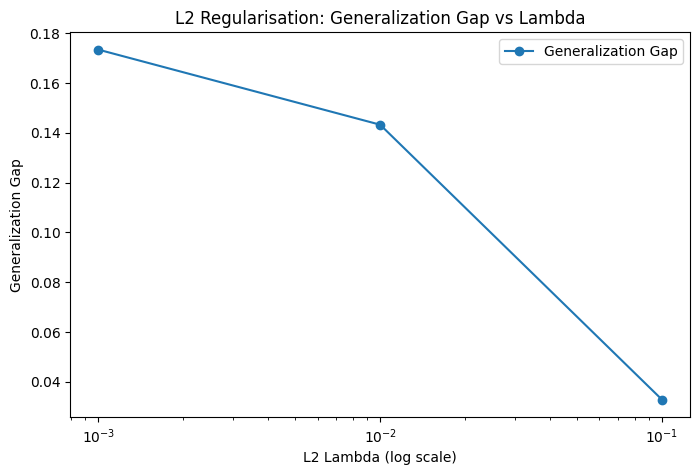

In [271]:
l2_lambdas = [0.001, 0.01, 0.1]
l2_gaps = [acc_l2_001_train - acc_l2_001_val,
           acc_l2_01_train - acc_l2_01_val,
           acc_l2_1_train - acc_l2_1_val]

plt.figure(figsize=(8,5))
plt.plot(l2_lambdas, l2_gaps, marker='o', label='Generalization Gap')
plt.xscale('log')
plt.xlabel("L2 Lambda (log scale)")
plt.ylabel("Generalization Gap")
plt.title("L2 Regularisation: Generalization Gap vs Lambda")
plt.legend()
plt.show()

Plot the generalisation gap against dropout rate, for the same purpose.

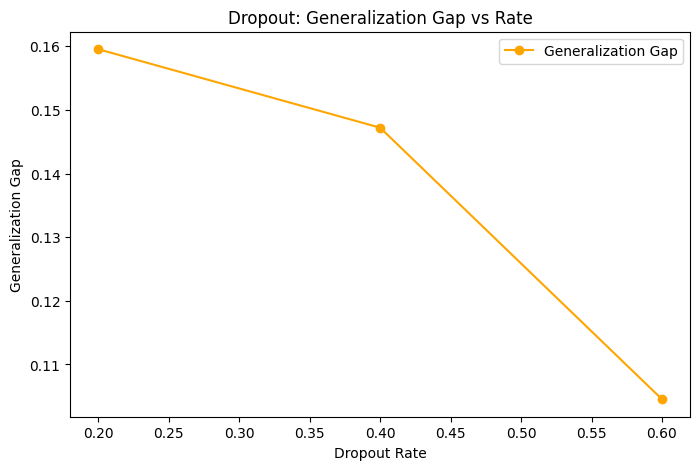

In [272]:
dropout_rates = [0.2, 0.4, 0.6]
dropout_gaps = [acc_drop_02_train - acc_drop_02_val,
                acc_drop_04_train - acc_drop_04_val,
                acc_drop_06_train - acc_drop_06_val]

plt.figure(figsize=(8,5))
plt.plot(dropout_rates, dropout_gaps, marker='o', color='orange', label='Generalization Gap')
plt.xlabel("Dropout Rate")
plt.ylabel("Generalization Gap")
plt.title("Dropout: Generalization Gap vs Rate")
plt.legend()
plt.show()

## Part 6 Conclusion: Comparing Regularisation Methods

Comparing gap reduction against training-accuracy cost, **more training data** gave the 
best trade-off. Using 20k samples reduced the gap from 17.25% to 10.18% (a 7-point drop) 
while training accuracy only fell from 100% to 98.26% — a very small cost. The 10k version 
showed a similar pattern (gap down to 12.46%, training accuracy still 98.84%).

In contrast, L2 (lambda=0.1) and Early Stopping shrank the gap the most in absolute terms 
(to 1.4% and 5.1%), but both did so by sacrificing a large amount of training accuracy 
(down to 67.5% and 82.6% respectively) , meaning the model lost real learning capacity, 
not just memorization.

Dropout (0.6) and moderate L2 (0.01) gave balanced but smaller improvements, without 
either extreme.

Overall, adding more data was the most efficient fix: it closed the gap substantially 
while barely touching the model's ability to fit the training data.

### Part 7: Hyperparameter Tuning with k-Fold Cross-Validation
Define the search space for three hyperparameters: learning rate, hidden layer width, and dropout rate.

In [273]:
import random
from sklearn.model_selection import KFold

random.seed(42)
np.random.seed(42)

learning_rates = [0.0001, 0.0005, 0.001, 0.005, 0.01]
hidden_widths = [64, 128, 256, 512]
dropout_rates = [0.0, 0.2, 0.3, 0.4, 0.5]

print("Learning rates:", learning_rates)
print("Hidden widths:", hidden_widths)
print("Dropout rates:", dropout_rates)

Learning rates: [0.0001, 0.0005, 0.001, 0.005, 0.01]
Hidden widths: [64, 128, 256, 512]
Dropout rates: [0.0, 0.2, 0.3, 0.4, 0.5]


Randomly generate 12 hyperparameter configurations to try, as required by the assignment (random search).

In [274]:
configs = []
for i in range(12):
    config = {
        'learning_rate': random.choice(learning_rates),
        'hidden_width': random.choice(hidden_widths),
        'dropout_rate': random.choice(dropout_rates)
    }
    configs.append(config)

for i, c in enumerate(configs):
    print(f"Config {i+1}: {c}")

Config 1: {'learning_rate': 0.0001, 'hidden_width': 64, 'dropout_rate': 0.3}
Config 2: {'learning_rate': 0.0005, 'hidden_width': 128, 'dropout_rate': 0.2}
Config 3: {'learning_rate': 0.0001, 'hidden_width': 64, 'dropout_rate': 0.5}
Config 4: {'learning_rate': 0.005, 'hidden_width': 64, 'dropout_rate': 0.0}
Config 5: {'learning_rate': 0.0001, 'hidden_width': 128, 'dropout_rate': 0.2}
Config 6: {'learning_rate': 0.01, 'hidden_width': 64, 'dropout_rate': 0.5}
Config 7: {'learning_rate': 0.0005, 'hidden_width': 512, 'dropout_rate': 0.2}
Config 8: {'learning_rate': 0.005, 'hidden_width': 256, 'dropout_rate': 0.0}
Config 9: {'learning_rate': 0.0005, 'hidden_width': 512, 'dropout_rate': 0.3}
Config 10: {'learning_rate': 0.001, 'hidden_width': 128, 'dropout_rate': 0.2}
Config 11: {'learning_rate': 0.001, 'hidden_width': 64, 'dropout_rate': 0.0}
Config 12: {'learning_rate': 0.005, 'hidden_width': 64, 'dropout_rate': 0.3}


Prepare a smaller 5,000-sample subset and set up 5-fold cross-validation, to keep the search reasonably fast.

In [275]:
np.random.seed(42)
cv_indices = np.random.choice(X_train.shape[0], 5000, replace=False)
X_cv = X_train[cv_indices]
y_cv_onehot = y_train_onehot[cv_indices]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("CV data shape:", X_cv.shape)

CV data shape: (5000, 784)


Define a function that trains and evaluates one configuration across all 5 folds and returns its mean and standard deviation accuracy.

In [276]:
def evaluate_config(config, X_cv, y_cv_onehot, kf):
    fold_accuracies = []
    
    for train_idx, val_idx in kf.split(X_cv):
        X_fold_train, X_fold_val = X_cv[train_idx], X_cv[val_idx]
        y_fold_train, y_fold_val = y_cv_onehot[train_idx], y_cv_onehot[val_idx]
        
        model_cv = Sequential()
        model_cv.add(Dense(config['hidden_width'], input_dim=784, activation='relu'))
        model_cv.add(Dropout(config['dropout_rate']))
        model_cv.add(Dense(config['hidden_width'], activation='relu'))
        model_cv.add(Dropout(config['dropout_rate']))
        model_cv.add(Dense(10, activation='softmax'))
        
        model_cv.compile(optimizer=Adam(learning_rate=config['learning_rate']),
                          loss='categorical_crossentropy', metrics=['accuracy'])
        
        model_cv.fit(X_fold_train, y_fold_train, epochs=10, batch_size=64, verbose=0)
        
        _, fold_acc = model_cv.evaluate(X_fold_val, y_fold_val, verbose=0)
        fold_accuracies.append(fold_acc)
    
    return np.mean(fold_accuracies), np.std(fold_accuracies)

Run 5-fold cross-validation for all 12 configurations.

In [278]:
cv_results = []

for i, config in enumerate(configs):
    mean_acc, std_acc = evaluate_config(config, X_cv, y_cv_onehot, kf)
    cv_results.append({'config': config, 'mean_acc': mean_acc, 'std_acc': std_acc})
    print(f"Config {i+1}/12 done - Mean CV Accuracy: {mean_acc:.4f}, Std: {std_acc:.4f}")

Config 1/12 done - Mean CV Accuracy: 0.7280, Std: 0.0105
Config 2/12 done - Mean CV Accuracy: 0.8232, Std: 0.0115
Config 3/12 done - Mean CV Accuracy: 0.6766, Std: 0.0241
Config 4/12 done - Mean CV Accuracy: 0.8250, Std: 0.0088
Config 5/12 done - Mean CV Accuracy: 0.7788, Std: 0.0153
Config 6/12 done - Mean CV Accuracy: 0.7242, Std: 0.0276
Config 7/12 done - Mean CV Accuracy: 0.8488, Std: 0.0117
Config 8/12 done - Mean CV Accuracy: 0.8348, Std: 0.0137
Config 9/12 done - Mean CV Accuracy: 0.8370, Std: 0.0159
Config 10/12 done - Mean CV Accuracy: 0.8328, Std: 0.0170
Config 11/12 done - Mean CV Accuracy: 0.8290, Std: 0.0125
Config 12/12 done - Mean CV Accuracy: 0.8088, Std: 0.0144


Sort and report the top 5 configurations by mean cross-validation accuracy.

In [279]:
cv_results_sorted = sorted(cv_results, key=lambda x: x['mean_acc'], reverse=True)

print("Top 5 Configurations:\n")
for i, result in enumerate(cv_results_sorted[:5]):
    print(f"Rank {i+1}: {result['config']}")
    print(f"  Mean CV Accuracy: {result['mean_acc']:.4f}, Std: {result['std_acc']:.4f}\n")

Top 5 Configurations:

Rank 1: {'learning_rate': 0.0005, 'hidden_width': 512, 'dropout_rate': 0.2}
  Mean CV Accuracy: 0.8488, Std: 0.0117

Rank 2: {'learning_rate': 0.0005, 'hidden_width': 512, 'dropout_rate': 0.3}
  Mean CV Accuracy: 0.8370, Std: 0.0159

Rank 3: {'learning_rate': 0.005, 'hidden_width': 256, 'dropout_rate': 0.0}
  Mean CV Accuracy: 0.8348, Std: 0.0137

Rank 4: {'learning_rate': 0.001, 'hidden_width': 128, 'dropout_rate': 0.2}
  Mean CV Accuracy: 0.8328, Std: 0.0170

Rank 5: {'learning_rate': 0.001, 'hidden_width': 64, 'dropout_rate': 0.0}
  Mean CV Accuracy: 0.8290, Std: 0.0125



Select the best configuration found by the search.

In [280]:
best_config = cv_results_sorted[0]['config']
print("Selected (Best) Configuration:", best_config)

Selected (Best) Configuration: {'learning_rate': 0.0005, 'hidden_width': 512, 'dropout_rate': 0.2}


Build the final model using the best configuration.

In [281]:
final_model = Sequential()
final_model.add(Dense(best_config['hidden_width'], input_dim=784, activation='relu'))
final_model.add(Dropout(best_config['dropout_rate']))
final_model.add(Dense(best_config['hidden_width'], activation='relu'))
final_model.add(Dropout(best_config['dropout_rate']))
final_model.add(Dense(10, activation='softmax'))

final_model.compile(optimizer=Adam(learning_rate=best_config['learning_rate']),
                     loss='categorical_crossentropy', metrics=['accuracy'])

final_model.summary()

Model: "sequential_211"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_693 (Dense)               │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_326 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_694 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_327 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_695 (Dense)               │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

Train the final model on the full training set, combining the best hyperparameters with the "more data" insight from Part 6.

In [282]:
history_final = final_model.fit(X_train, y_train_onehot,
                                 validation_data=(X_val, y_val_onehot),
                                 epochs=30,
                                 batch_size=128,
                                 verbose=1)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7954 - loss: 0.5753 - val_accuracy: 0.8388 - val_loss: 0.4428
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8518 - loss: 0.4061 - val_accuracy: 0.8594 - val_loss: 0.3791
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8692 - loss: 0.3621 - val_accuracy: 0.8732 - val_loss: 0.3445
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8764 - loss: 0.3381 - val_accuracy: 0.8780 - val_loss: 0.3300
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8831 - loss: 0.3180 - val_accuracy: 0.8828 - val_loss: 0.3246
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8903 - loss: 0.3010 - val_accuracy: 0.8691 - val_loss: 0.3487
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8949 - loss: 0.2863 - val_accuracy: 0.8857 - val_loss: 0.3133
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8981 - loss: 0.2780 - val_accuracy: 0.

Evaluate the final model on the validation set.

In [283]:
loss_final, acc_final = final_model.evaluate(X_val, y_val_onehot, verbose=0)
print("Final Model Validation Loss:", loss_final)
print("Final Model Validation Accuracy:", acc_final)

Final Model Validation Loss: 0.3223479092121124
Final Model Validation Accuracy: 0.9004335999488831


Evaluate the final model on the held-out test set — this is the only place in the notebook the test set is used. Report accuracy, macro precision, macro recall, and macro F1.

In [284]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

y_pred_probs = final_model.predict(X_test)
y_pred_final = np.argmax(y_pred_probs, axis=1)

test_accuracy = accuracy_score(y_test, y_pred_final)
test_precision = precision_score(y_test, y_pred_final, average='macro')
test_recall = recall_score(y_test, y_pred_final, average='macro')
test_f1 = f1_score(y_test, y_pred_final, average='macro')

print("Test Accuracy:", test_accuracy)
print("Test Macro Precision:", test_precision)
print("Test Macro Recall:", test_recall)
print("Test Macro F1:", test_f1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Accuracy: 0.9035903590359036
Test Macro Precision: 0.9032102114953438
Test Macro Recall: 0.9035856856856856
Test Macro F1: 0.9028919461616184


Plot the confusion matrix for the final model's predictions on the test set.

<Figure size 1000x800 with 0 Axes>

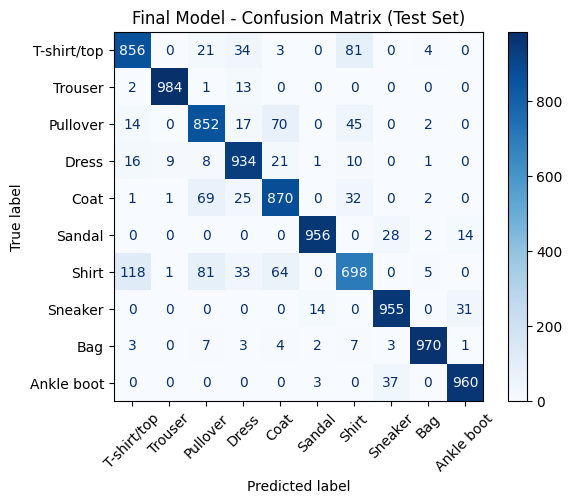

In [285]:
cm_final = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=class_names)

plt.figure(figsize=(10,8))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Final Model - Confusion Matrix (Test Set)")
plt.show()

## Part 7 Conclusion

**Search Space:** learning rate {0.0001, 0.0005, 0.001, 0.005, 0.01}, hidden width 
{64, 128, 256, 512}, dropout rate {0.0, 0.2, 0.3, 0.4, 0.5}

**Top 5 Configurations (5-fold CV):**
1. lr=0.0005, width=512, dropout=0.2 → Mean Acc: 84.88%, Std: 0.0117
2. lr=0.0005, width=512, dropout=0.3 → Mean Acc: 83.70%, Std: 0.0159
3. lr=0.005, width=256, dropout=0.0 → Mean Acc: 83.48%, Std: 0.0137
4. lr=0.001, width=128, dropout=0.2 → Mean Acc: 83.28%, Std: 0.0170
5. lr=0.001, width=64, dropout=0.0 → Mean Acc: 82.90%, Std: 0.0125

**Selected Configuration:** lr=0.0005, width=512, dropout=0.2

**Final Test Set Results:**
- Test Accuracy: 90.36%
- Macro Precision: 90.32%
- Macro Recall: 90.36%
- Macro F1: 90.29%

**Improvement over Part 2 baseline:** The Part 2 baseline model (128-64 ReLU network) 
reached around 88.97% validation accuracy. The final tuned model reached 90.36% test 
accuracy , an improvement of approximately **1.4 percentage points**. This modest but 
real improvement comes from combining a wider hidden layer (512 units), a lower tuned 
learning rate, light dropout regularisation, and training on the full training set 
rather than a small subset.

The confusion matrix shows the most common misclassifications are between visually 
similar classes , Shirt is often confused with T-shirt/top, Pullover, and Coat, which 
makes sense given how similar these clothing items look in low-resolution grayscale images.